<a href="https://colab.research.google.com/github/TanyaGupta37/Student-Performance-Analysis/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Settings
sns.set(style="whitegrid")

## Upload Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving student-por.csv to student-por (1).csv


In [3]:
df = pd.read_csv('student-por.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


Basic ops

In [4]:
print("Shape:", df.shape)
df.info()

Shape: (649, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    objec

In [5]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [6]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


## Distribution Analysis of Target Varable

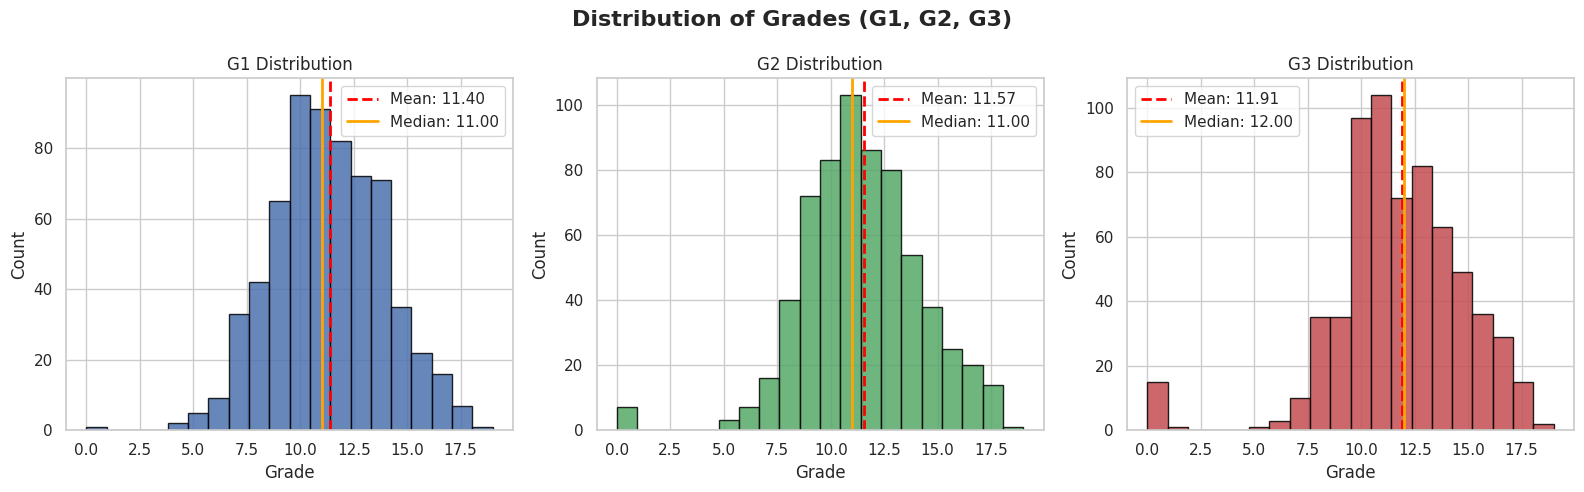


 Grade Statistics:
           G1      G2      G3
count  649.00  649.00  649.00
mean    11.40   11.57   11.91
std      2.75    2.91    3.23
min      0.00    0.00    0.00
25%     10.00   10.00   10.00
50%     11.00   11.00   12.00
75%     13.00   13.00   14.00
max     19.00   19.00   19.00


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribution of Grades (G1, G2, G3)", fontsize=16, fontweight='bold')

for i, col in enumerate(['G1', 'G2', 'G3']):
    axes[i].hist(df[col], bins=20, color=['#4C72B0','#55A868','#C44E52'][i], edgecolor='black', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-', linewidth=2, label=f'Median: {df[col].median():.2f}')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Grade')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.tight_layout()
plt.savefig('grade_distributions.png', dpi=150)
plt.show()

print("\n Grade Statistics:")
print(df[['G1','G2','G3']].describe().round(2))

# Categorical Feature Analysis

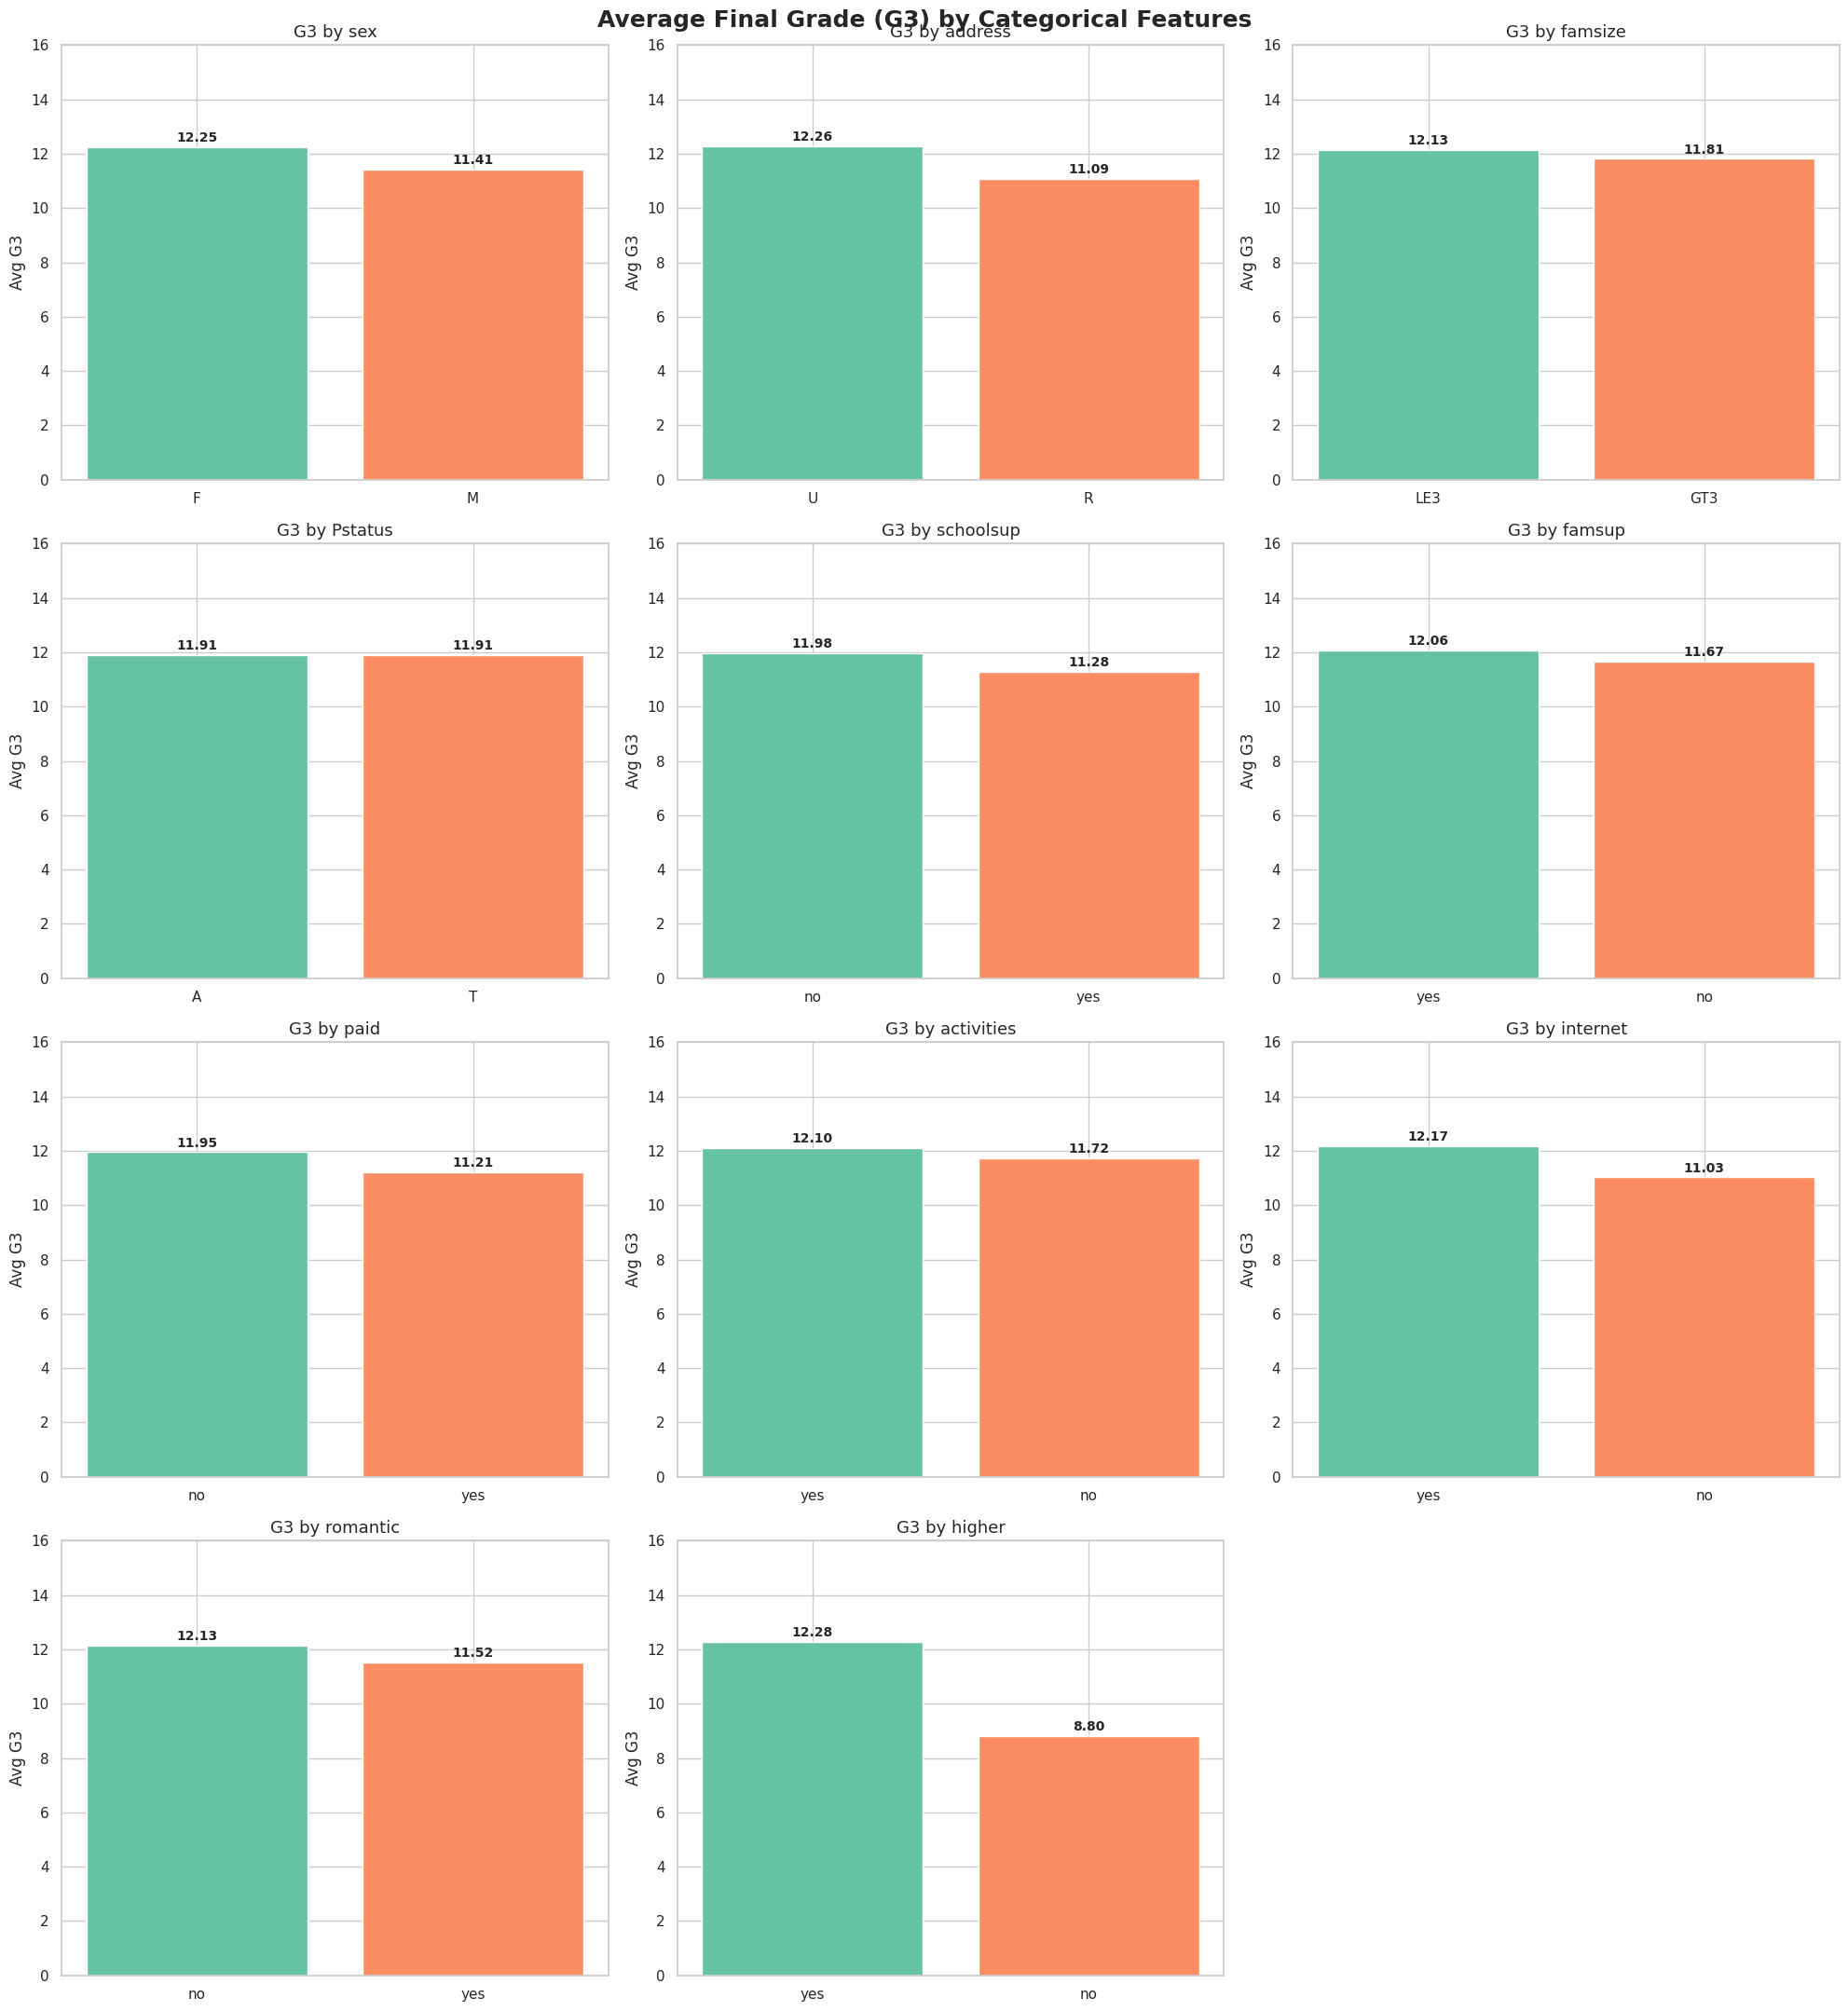

In [10]:
cat_cols = ['sex', 'address', 'famsize', 'Pstatus', 'schoolsup',
            'famsup', 'paid', 'activities', 'internet', 'romantic', 'higher']

fig, axes = plt.subplots(4, 3, figsize=(20, 22))
fig.suptitle("Average Final Grade (G3) by Categorical Features", fontsize=18, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    group = df.groupby(col)['G3'].mean().sort_values(ascending=False)
    bars = axes[i].bar(group.index, group.values, color=sns.color_palette("Set2", len(group)))
    axes[i].set_title(f'G3 by {col}', fontsize=13)
    axes[i].set_ylabel('Avg G3')
    axes[i].set_ylim(0, 16)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                     f'{bar.get_height():.2f}', ha='center', fontsize=10, fontweight='bold')

axes[-1].set_visible(False)  # hide the empty last cell
plt.tight_layout()
plt.savefig('categorical_vs_G3.png', dpi=150)
plt.show()

# Correlation Heatmap

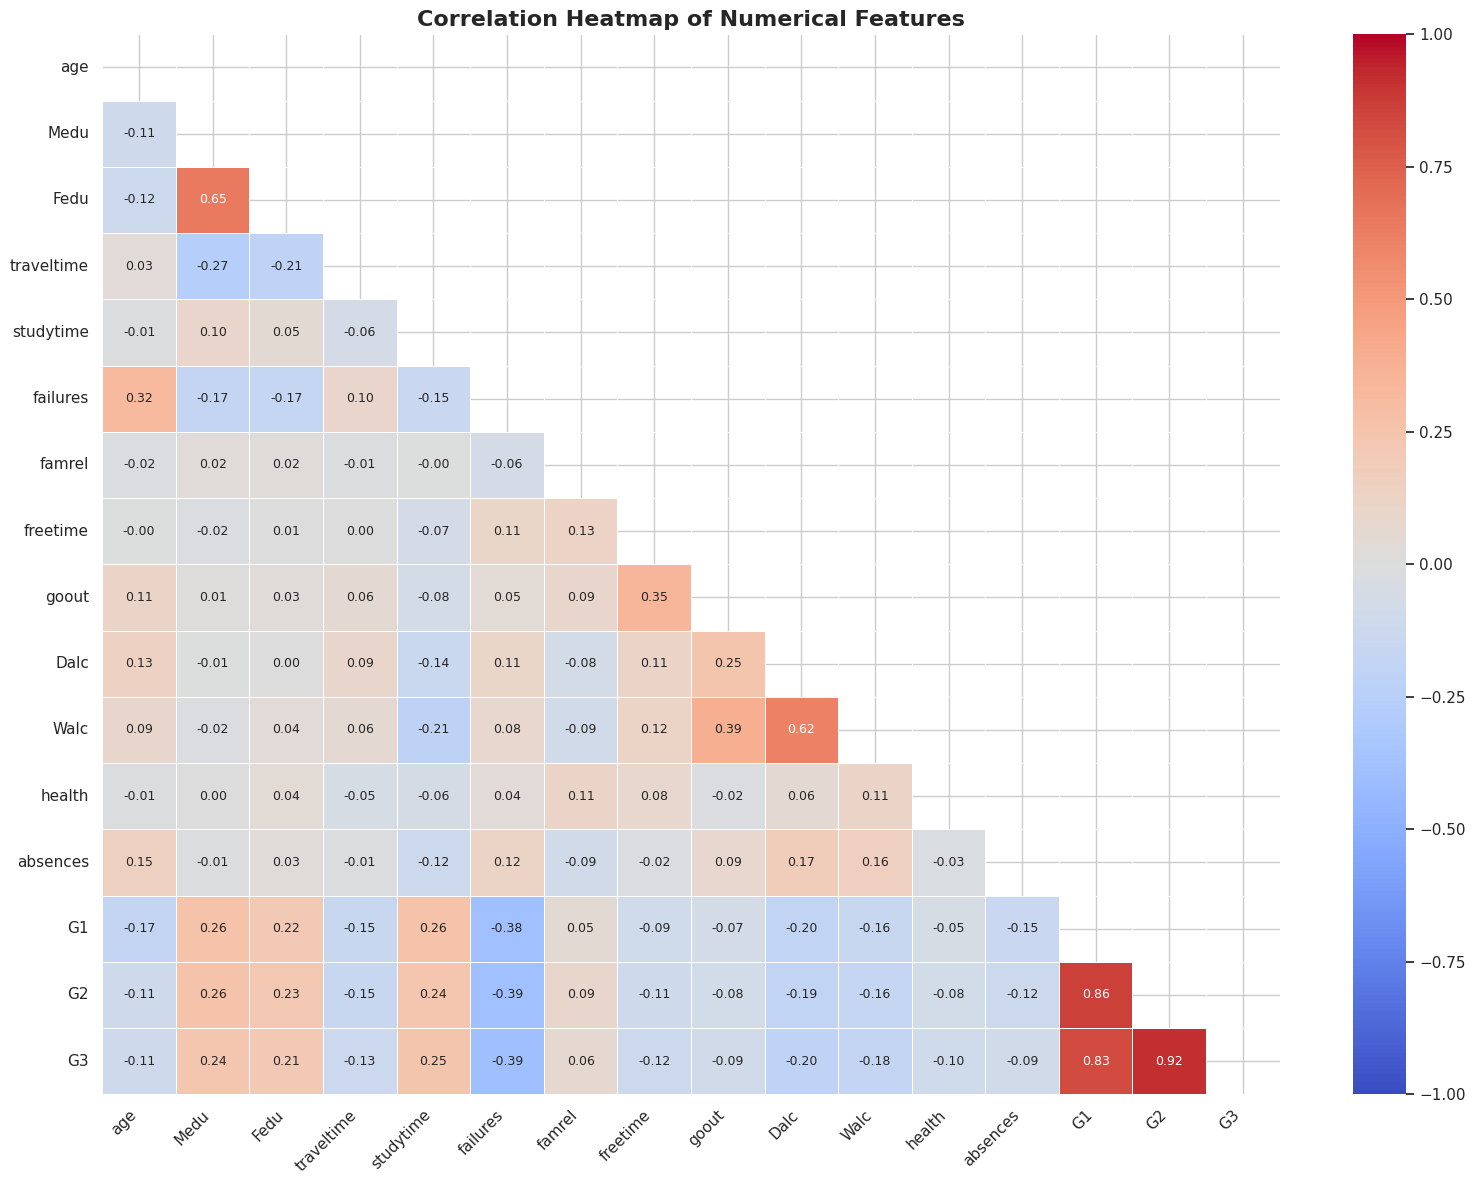


🔗 Top Correlations with Final Grade (G3):
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316


In [11]:
plt.figure(figsize=(16, 12))
corr = df.select_dtypes(include='number').corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, linecolor='white', vmin=-1, vmax=1,
            annot_kws={"size": 9})

plt.title("Correlation Heatmap of Numerical Features", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

# Print top correlations with G3
print("\n🔗 Top Correlations with Final Grade (G3):")
g3_corr = corr['G3'].drop('G3').sort_values(ascending=False)
print(g3_corr.to_string())

# Numerical Features vs Final Grade(G3)

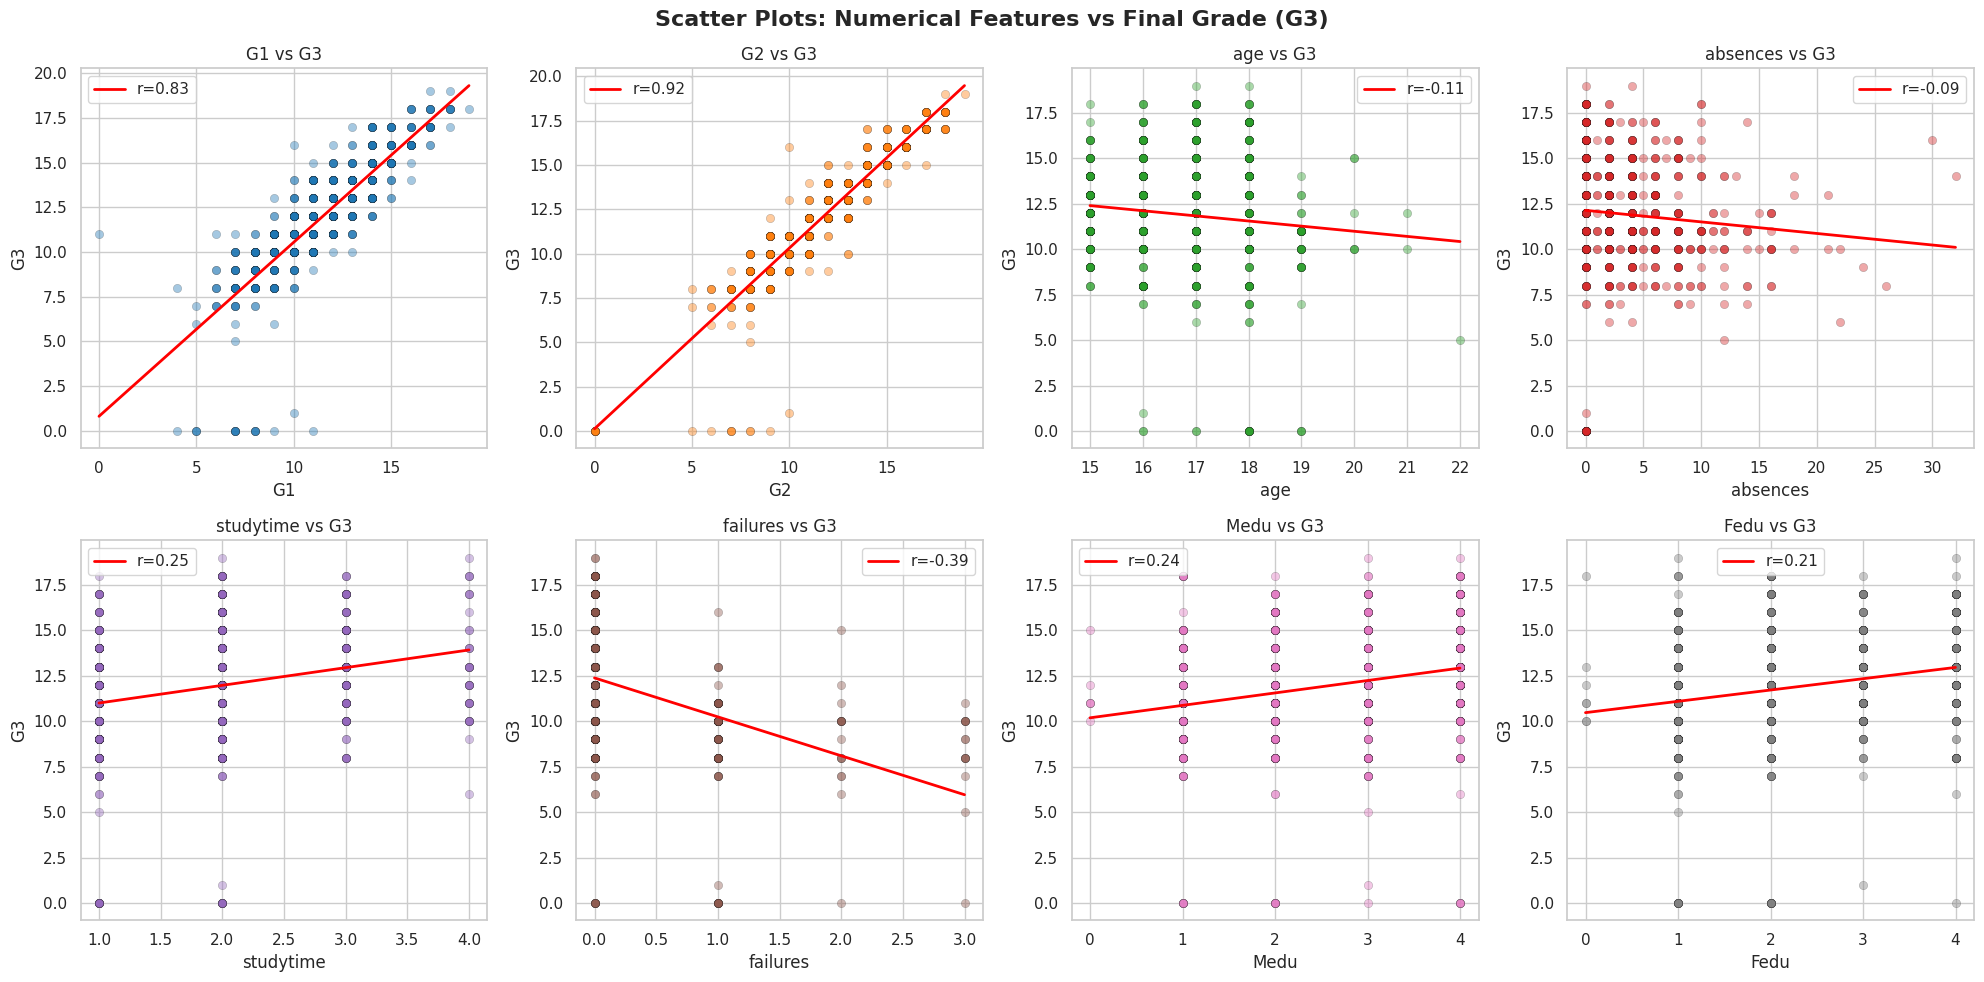

In [12]:
num_features = ['G1', 'G2', 'age', 'absences', 'studytime', 'failures', 'Medu', 'Fedu']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Scatter Plots: Numerical Features vs Final Grade (G3)", fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].scatter(df[col], df['G3'], alpha=0.4, color=sns.color_palette("tab10")[i], edgecolors='k', linewidths=0.3)
    # Trend line
    m, b = np.polyfit(df[col], df['G3'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m*x_line + b, color='red', linewidth=2, label=f'r={df[col].corr(df["G3"]):.2f}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('G3')
    axes[i].set_title(f'{col} vs G3')
    axes[i].legend()

plt.tight_layout()
plt.savefig('scatter_vs_G3.png', dpi=150)
plt.show()

# Box Plots - G3 Distribution

/tmp/ipykernel_2754/2850556747.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=x, y=y, palette='Set3', ax=ax)
/tmp/ipykernel_2754/2850556747.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=x, y=y, palette='Set3', ax=ax)
/tmp/ipykernel_2754/2850556747.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=x, y=y, palette='Set3', ax=ax)
/tmp/ipykernel_2754/2850556747.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to

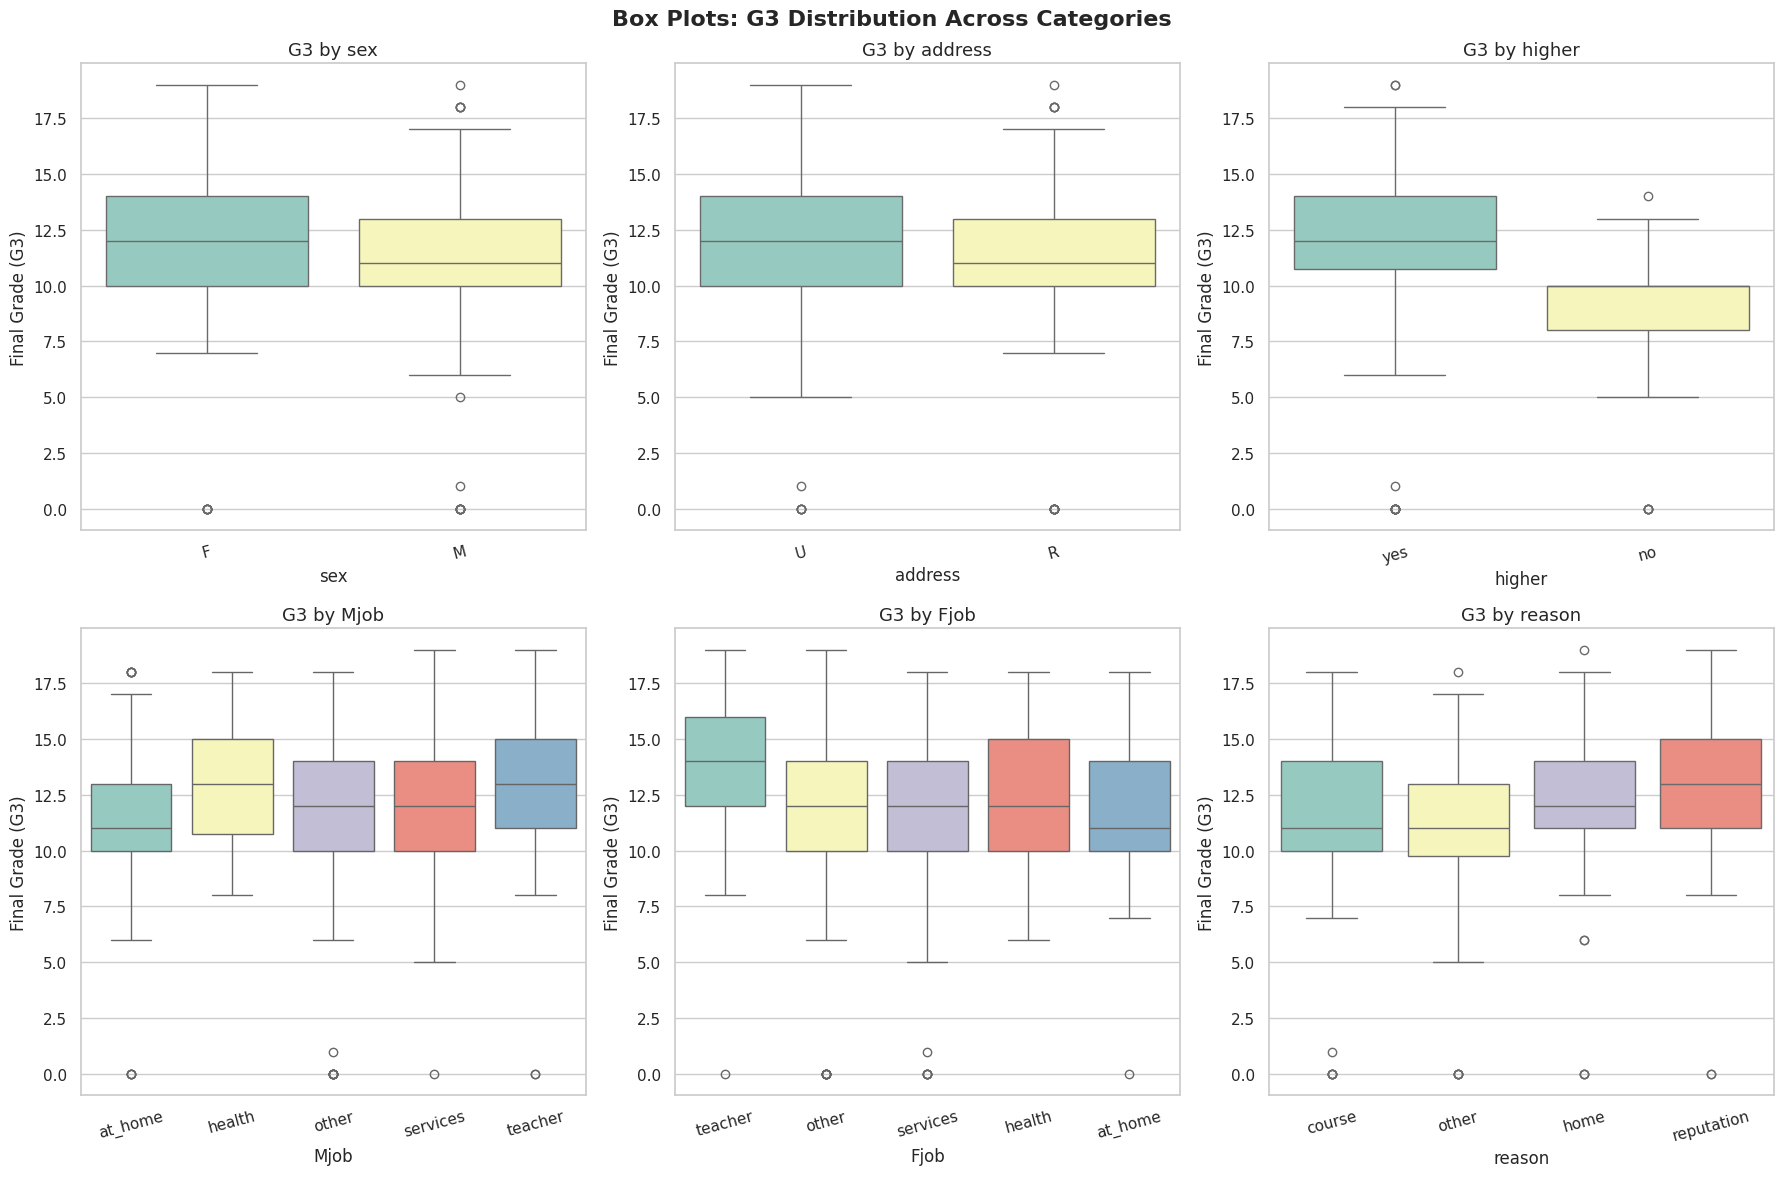

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Box Plots: G3 Distribution Across Categories", fontsize=16, fontweight='bold')

pairs = [
    ('sex', 'G3'), ('address', 'G3'), ('higher', 'G3'),
    ('Mjob', 'G3'), ('Fjob', 'G3'), ('reason', 'G3')
]

for ax, (x, y) in zip(axes.flatten(), pairs):
    sns.boxplot(data=df, x=x, y=y, palette='Set3', ax=ax)
    ax.set_title(f'G3 by {x}', fontsize=13)
    ax.set_xlabel(x)
    ax.set_ylabel('Final Grade (G3)')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('boxplots_G3.png', dpi=150)
plt.show()

# Alcohol Consumption Analysis

/tmp/ipykernel_2754/866101280.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Dalc', y='G3', palette='YlOrRd', ax=axes[0,0])
/tmp/ipykernel_2754/866101280.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Walc', y='G3', palette='OrRd', ax=axes[0,1])
/tmp/ipykernel_2754/866101280.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='total_alc', y='G3', palette='Reds', ax=axes[0,2])
/tmp/ipykernel_2754/866101280.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be

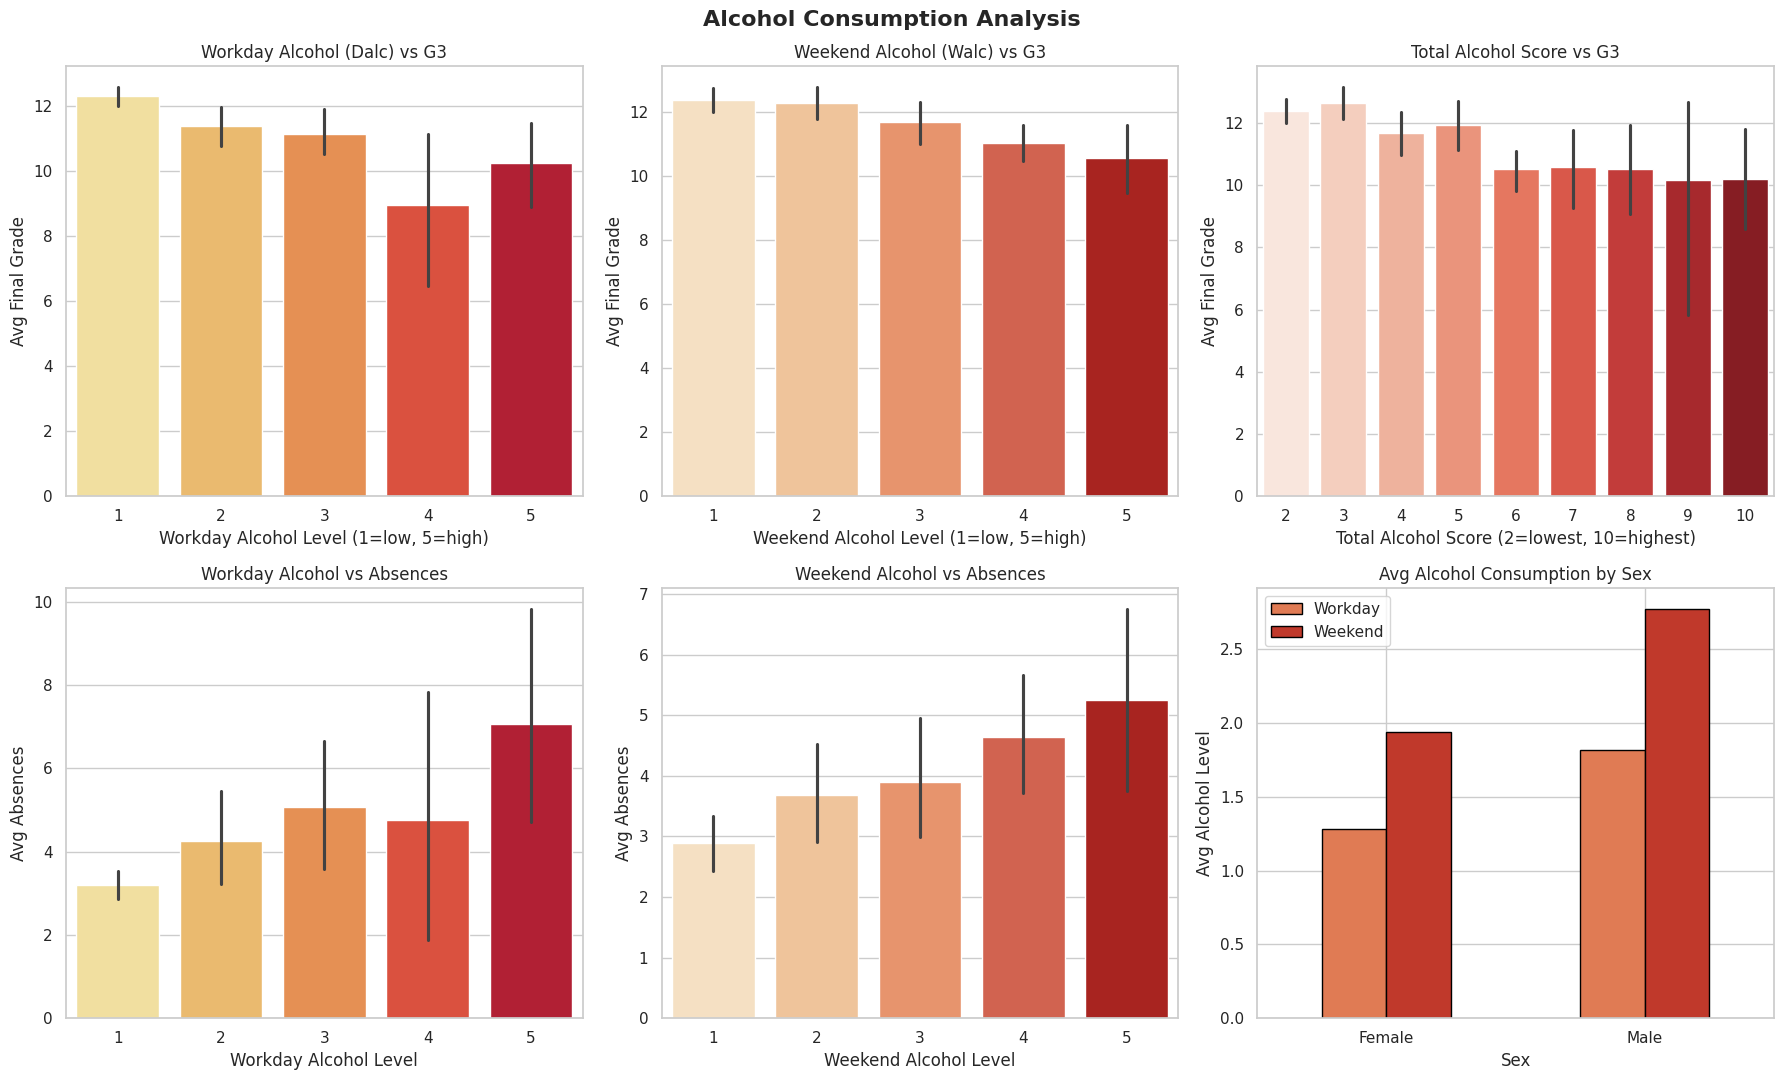


🍺 Correlation of Alcohol with G3:
  Dalc vs G3: -0.205
  Walc vs G3: -0.177
  Total Alc vs G3: -0.209


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Alcohol Consumption Analysis", fontsize=16, fontweight='bold')

# Workday alcohol vs G3
sns.barplot(data=df, x='Dalc', y='G3', palette='YlOrRd', ax=axes[0,0])
axes[0,0].set_title('Workday Alcohol (Dalc) vs G3')
axes[0,0].set_xlabel('Workday Alcohol Level (1=low, 5=high)')
axes[0,0].set_ylabel('Avg Final Grade')

# Weekend alcohol vs G3
sns.barplot(data=df, x='Walc', y='G3', palette='OrRd', ax=axes[0,1])
axes[0,1].set_title('Weekend Alcohol (Walc) vs G3')
axes[0,1].set_xlabel('Weekend Alcohol Level (1=low, 5=high)')
axes[0,1].set_ylabel('Avg Final Grade')

# Combined alcohol score
df['total_alc'] = df['Dalc'] + df['Walc']
sns.barplot(data=df, x='total_alc', y='G3', palette='Reds', ax=axes[0,2])
axes[0,2].set_title('Total Alcohol Score vs G3')
axes[0,2].set_xlabel('Total Alcohol Score (2=lowest, 10=highest)')
axes[0,2].set_ylabel('Avg Final Grade')

# Alcohol vs absences
sns.barplot(data=df, x='Dalc', y='absences', palette='YlOrRd', ax=axes[1,0])
axes[1,0].set_title('Workday Alcohol vs Absences')
axes[1,0].set_xlabel('Workday Alcohol Level')
axes[1,0].set_ylabel('Avg Absences')

# Weekend alcohol vs absences
sns.barplot(data=df, x='Walc', y='absences', palette='OrRd', ax=axes[1,1])
axes[1,1].set_title('Weekend Alcohol vs Absences')
axes[1,1].set_xlabel('Weekend Alcohol Level')
axes[1,1].set_ylabel('Avg Absences')

# Sex vs alcohol
alc_sex = df.groupby('sex')[['Dalc','Walc']].mean()
alc_sex.plot(kind='bar', ax=axes[1,2], color=['#E07B54','#C0392B'], edgecolor='black')
axes[1,2].set_title('Avg Alcohol Consumption by Sex')
axes[1,2].set_xlabel('Sex')
axes[1,2].set_ylabel('Avg Alcohol Level')
axes[1,2].set_xticklabels(['Female','Male'], rotation=0)
axes[1,2].legend(['Workday','Weekend'])

plt.tight_layout()
plt.savefig('alcohol_analysis.png', dpi=150)
plt.show()

print("\n🍺 Correlation of Alcohol with G3:")
print(f"  Dalc vs G3: {df['Dalc'].corr(df['G3']):.3f}")
print(f"  Walc vs G3: {df['Walc'].corr(df['G3']):.3f}")
print(f"  Total Alc vs G3: {df['total_alc'].corr(df['G3']):.3f}")

# Parents' Education Level Analysis

/tmp/ipykernel_2754/888590550.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Medu', y='studytime', palette='Blues', ax=axes[1,0])
/tmp/ipykernel_2754/888590550.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels([edu_labels[i] for i in sorted(df['Medu'].unique())])
/tmp/ipykernel_2754/888590550.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Fedu', y='failures', palette='Greens', ax=axes[1,1])
/tmp/ipykernel_2754/888590550.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixe

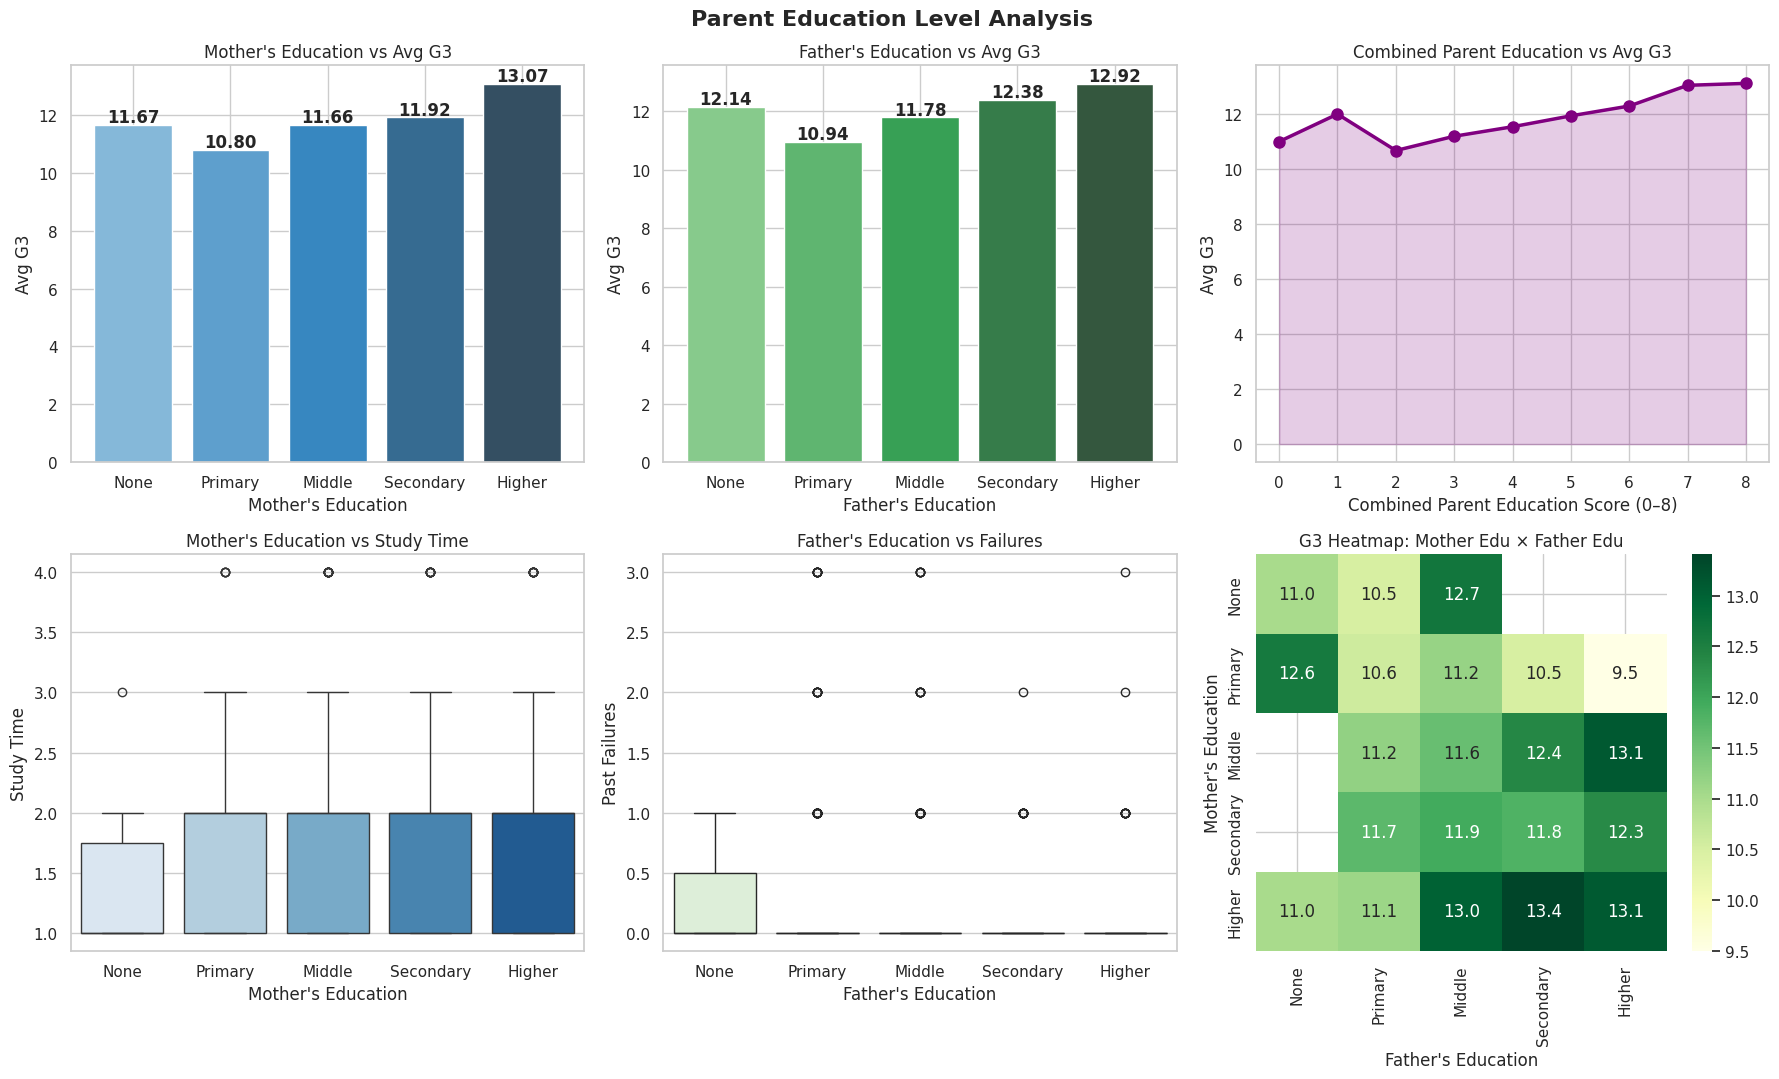

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Parent Education Level Analysis", fontsize=16, fontweight='bold')

edu_labels = {0:'None', 1:'Primary', 2:'Middle', 3:'Secondary', 4:'Higher'}

# Mother education vs G3
medu_avg = df.groupby('Medu')['G3'].mean()
axes[0,0].bar([edu_labels[k] for k in medu_avg.index], medu_avg.values, color=sns.color_palette("Blues_d", 5))
axes[0,0].set_title("Mother's Education vs Avg G3")
axes[0,0].set_ylabel('Avg G3')
axes[0,0].set_xlabel("Mother's Education")
for i, v in enumerate(medu_avg.values):
    axes[0,0].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

# Father education vs G3
fedu_avg = df.groupby('Fedu')['G3'].mean()
axes[0,1].bar([edu_labels[k] for k in fedu_avg.index], fedu_avg.values, color=sns.color_palette("Greens_d", 5))
axes[0,1].set_title("Father's Education vs Avg G3")
axes[0,1].set_ylabel('Avg G3')
axes[0,1].set_xlabel("Father's Education")
for i, v in enumerate(fedu_avg.values):
    axes[0,1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

# Combined parent education score
df['parent_edu'] = df['Medu'] + df['Fedu']
pedu_avg = df.groupby('parent_edu')['G3'].mean()
axes[0,2].plot(pedu_avg.index, pedu_avg.values, marker='o', color='purple', linewidth=2.5, markersize=8)
axes[0,2].fill_between(pedu_avg.index, pedu_avg.values, alpha=0.2, color='purple')
axes[0,2].set_title("Combined Parent Education vs Avg G3")
axes[0,2].set_ylabel('Avg G3')
axes[0,2].set_xlabel('Combined Parent Education Score (0–8)')

# Mother edu vs studytime
sns.boxplot(data=df, x='Medu', y='studytime', palette='Blues', ax=axes[1,0])
axes[1,0].set_title("Mother's Education vs Study Time")
axes[1,0].set_xticklabels([edu_labels[i] for i in sorted(df['Medu'].unique())])
axes[1,0].set_xlabel("Mother's Education")
axes[1,0].set_ylabel('Study Time')

# Father edu vs failures
sns.boxplot(data=df, x='Fedu', y='failures', palette='Greens', ax=axes[1,1])
axes[1,1].set_title("Father's Education vs Failures")
axes[1,1].set_xticklabels([edu_labels[i] for i in sorted(df['Fedu'].unique())])
axes[1,1].set_xlabel("Father's Education")
axes[1,1].set_ylabel('Past Failures')

# Heatmap: Medu vs Fedu avg G3
pivot = df.pivot_table(values='G3', index='Medu', columns='Fedu', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGn', ax=axes[1,2],
            xticklabels=[edu_labels[i] for i in pivot.columns],
            yticklabels=[edu_labels[i] for i in pivot.index])
axes[1,2].set_title("G3 Heatmap: Mother Edu × Father Edu")
axes[1,2].set_xlabel("Father's Education")
axes[1,2].set_ylabel("Mother's Education")

plt.tight_layout()
plt.savefig('parent_education_analysis.png', dpi=150)
plt.show()

# Failures and Study Time Analysis

/tmp/ipykernel_2754/2583772023.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='failures', y='G3', palette='Set2', ax=axes[0,1])
/tmp/ipykernel_2754/2583772023.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='studytime', y='failures', palette='coolwarm', ax=axes[1,2])
/tmp/ipykernel_2754/2583772023.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,2].set_xticklabels([study_labels[i] for i in sorted(df['studytime'].unique())])


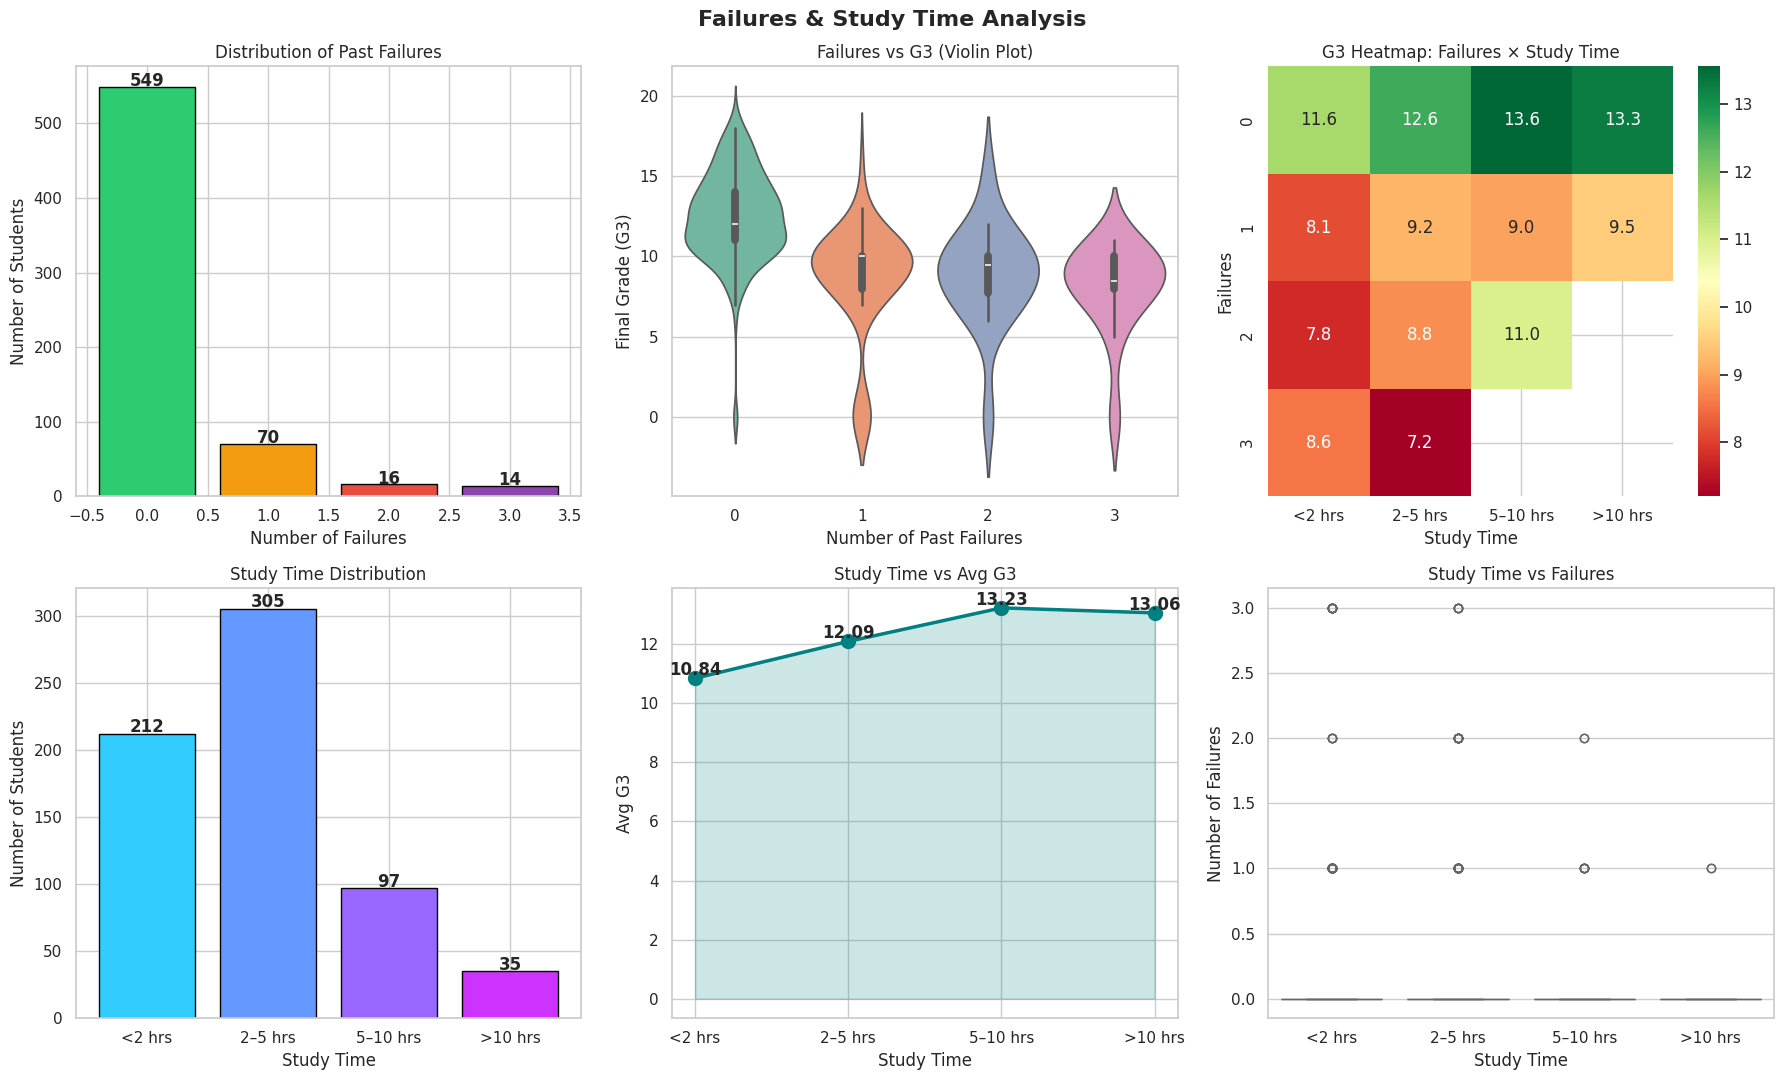

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Failures & Study Time Analysis", fontsize=16, fontweight='bold')

study_labels = {1:'<2 hrs', 2:'2–5 hrs', 3:'5–10 hrs', 4:'>10 hrs'}

# Failures count distribution
fail_counts = df['failures'].value_counts().sort_index()
axes[0,0].bar(fail_counts.index, fail_counts.values, color=['#2ecc71','#f39c12','#e74c3c','#8e44ad'], edgecolor='black')
axes[0,0].set_title('Distribution of Past Failures')
axes[0,0].set_xlabel('Number of Failures')
axes[0,0].set_ylabel('Number of Students')
for i, v in zip(fail_counts.index, fail_counts.values):
    axes[0,0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Failures vs G3 violin
sns.violinplot(data=df, x='failures', y='G3', palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Failures vs G3 (Violin Plot)')
axes[0,1].set_xlabel('Number of Past Failures')
axes[0,1].set_ylabel('Final Grade (G3)')

# Failures vs studytime heatmap
pivot2 = df.pivot_table(values='G3', index='failures', columns='studytime', aggfunc='mean')
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[0,2],
            xticklabels=[study_labels[i] for i in pivot2.columns])
axes[0,2].set_title('G3 Heatmap: Failures × Study Time')
axes[0,2].set_xlabel('Study Time')
axes[0,2].set_ylabel('Failures')

# Study time distribution
study_counts = df['studytime'].value_counts().sort_index()
axes[1,0].bar([study_labels[k] for k in study_counts.index], study_counts.values,
              color=sns.color_palette("cool", 4), edgecolor='black')
axes[1,0].set_title('Study Time Distribution')
axes[1,0].set_xlabel('Study Time')
axes[1,0].set_ylabel('Number of Students')
for i, v in enumerate(study_counts.values):
    axes[1,0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Study time vs G3
study_avg = df.groupby('studytime')['G3'].mean()
axes[1,1].plot([study_labels[k] for k in study_avg.index], study_avg.values,
               marker='o', color='teal', linewidth=2.5, markersize=10)
axes[1,1].fill_between(range(len(study_avg)), study_avg.values, alpha=0.2, color='teal')
axes[1,1].set_title('Study Time vs Avg G3')
axes[1,1].set_xlabel('Study Time')
axes[1,1].set_ylabel('Avg G3')
for i, v in enumerate(study_avg.values):
    axes[1,1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

# Study time vs failures
sns.boxplot(data=df, x='studytime', y='failures', palette='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Study Time vs Failures')
axes[1,2].set_xticklabels([study_labels[i] for i in sorted(df['studytime'].unique())])
axes[1,2].set_xlabel('Study Time')
axes[1,2].set_ylabel('Number of Failures')

plt.tight_layout()
plt.savefig('failures_studytime_analysis.png', dpi=150)
plt.show()

# Social Life vs Academic Performance

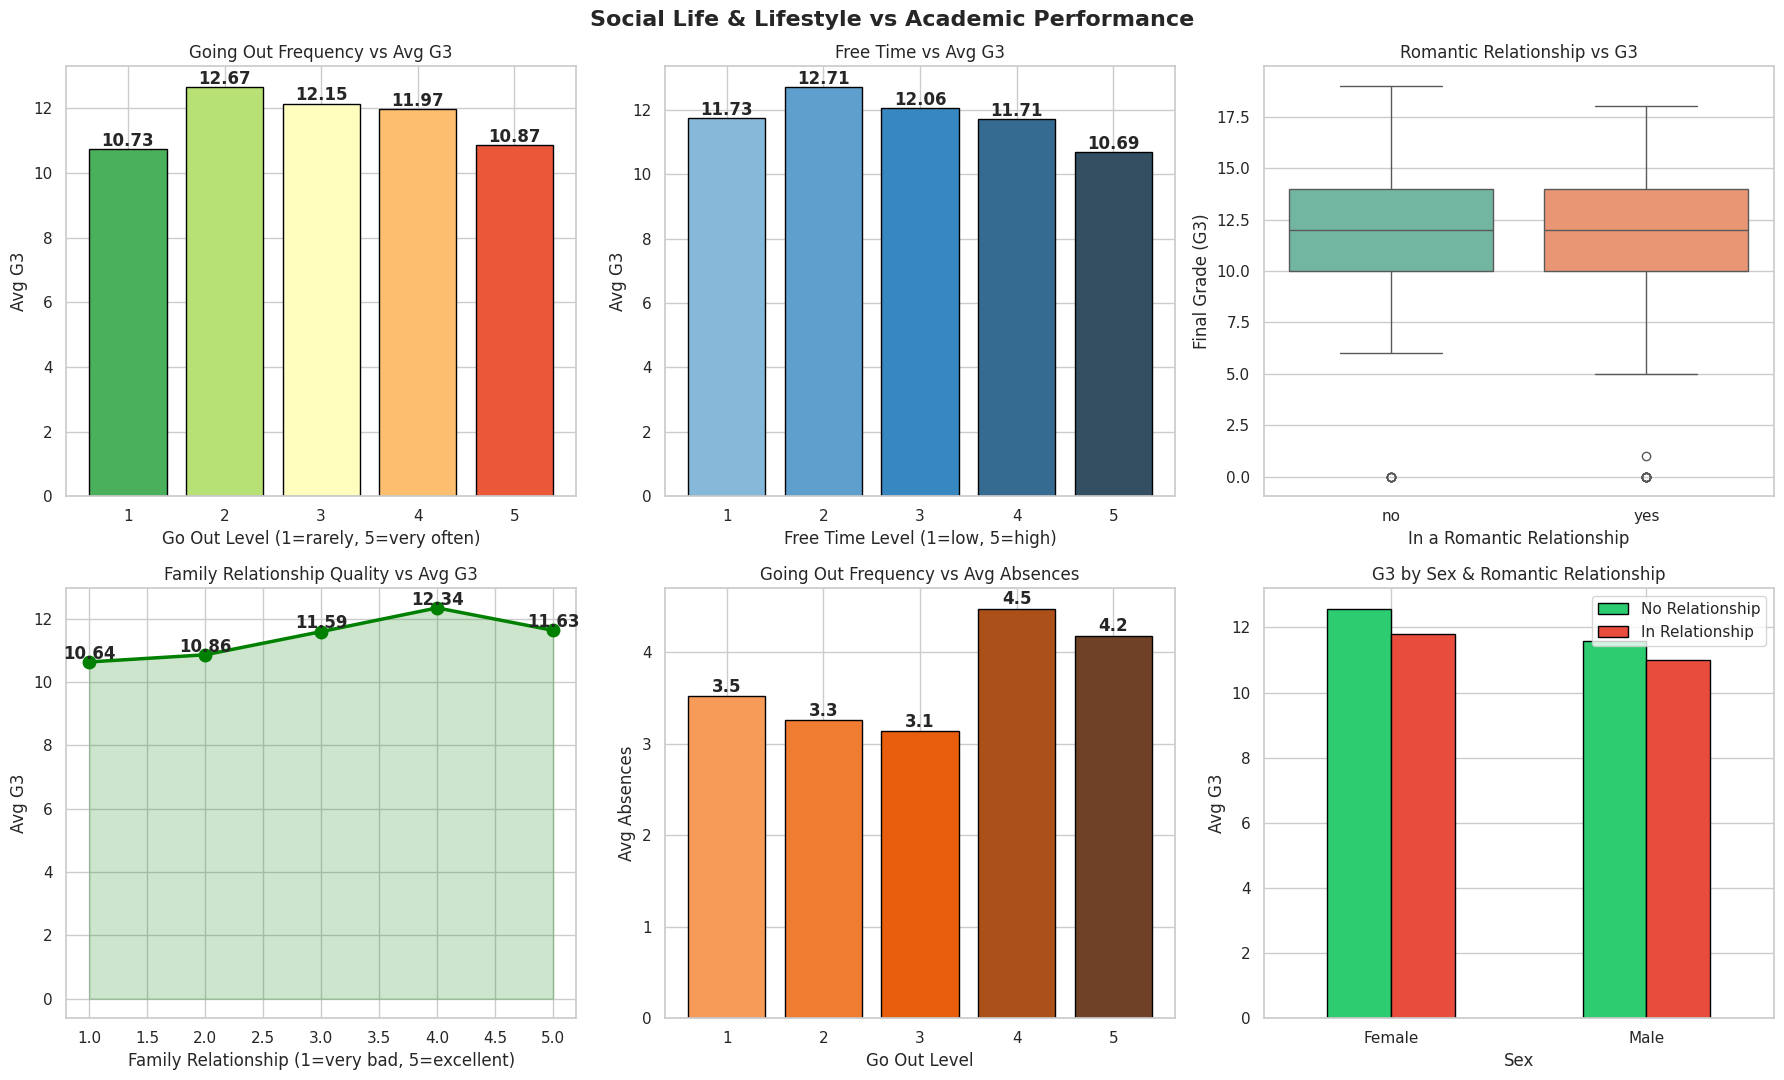

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Social Life & Lifestyle vs Academic Performance", fontsize=16, fontweight='bold')

# Go out vs G3
goout_avg = df.groupby('goout')['G3'].mean()
axes[0,0].bar(goout_avg.index, goout_avg.values, color=sns.color_palette("RdYlGn_r", 5), edgecolor='black')
axes[0,0].set_title('Going Out Frequency vs Avg G3')
axes[0,0].set_xlabel('Go Out Level (1=rarely, 5=very often)')
axes[0,0].set_ylabel('Avg G3')
for i, v in zip(goout_avg.index, goout_avg.values):
    axes[0,0].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

# Freetime vs G3
freetime_avg = df.groupby('freetime')['G3'].mean()
axes[0,1].bar(freetime_avg.index, freetime_avg.values, color=sns.color_palette("Blues_d", 5), edgecolor='black')
axes[0,1].set_title('Free Time vs Avg G3')
axes[0,1].set_xlabel('Free Time Level (1=low, 5=high)')
axes[0,1].set_ylabel('Avg G3')
for i, v in zip(freetime_avg.index, freetime_avg.values):
    axes[0,1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

# Romantic vs G3
sns.boxplot(data=df, x='romantic', y='G3', hue='romantic', palette='Set2', ax=axes[0,2], legend=False)
axes[0,2].set_title('Romantic Relationship vs G3')
axes[0,2].set_xlabel('In a Romantic Relationship')
axes[0,2].set_ylabel('Final Grade (G3)')

# Family relationship vs G3
famrel_avg = df.groupby('famrel')['G3'].mean()
axes[1,0].plot(famrel_avg.index, famrel_avg.values, marker='o', color='green',
               linewidth=2.5, markersize=9)
axes[1,0].fill_between(famrel_avg.index, famrel_avg.values, alpha=0.2, color='green')
axes[1,0].set_title('Family Relationship Quality vs Avg G3')
axes[1,0].set_xlabel('Family Relationship (1=very bad, 5=excellent)')
axes[1,0].set_ylabel('Avg G3')
for x, y in zip(famrel_avg.index, famrel_avg.values):
    axes[1,0].text(x, y + 0.1, f'{y:.2f}', ha='center', fontweight='bold')

# Goout vs absences
goout_abs = df.groupby('goout')['absences'].mean()
axes[1,1].bar(goout_abs.index, goout_abs.values, color=sns.color_palette("Oranges_d", 5), edgecolor='black')
axes[1,1].set_title('Going Out Frequency vs Avg Absences')
axes[1,1].set_xlabel('Go Out Level')
axes[1,1].set_ylabel('Avg Absences')
for i, v in zip(goout_abs.index, goout_abs.values):
    axes[1,1].text(i, v + 0.05, f'{v:.1f}', ha='center', fontweight='bold')

# Stacked: romantic + sex vs G3
pivot_rom = df.groupby(['sex','romantic'])['G3'].mean().unstack()
pivot_rom.plot(kind='bar', ax=axes[1,2], color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[1,2].set_title('G3 by Sex & Romantic Relationship')
axes[1,2].set_xlabel('Sex')
axes[1,2].set_ylabel('Avg G3')
axes[1,2].set_xticklabels(['Female','Male'], rotation=0)
axes[1,2].legend(['No Relationship','In Relationship'])

plt.tight_layout()
plt.savefig('social_life_analysis.png', dpi=150)
plt.show()

# Health and Absences Analysis

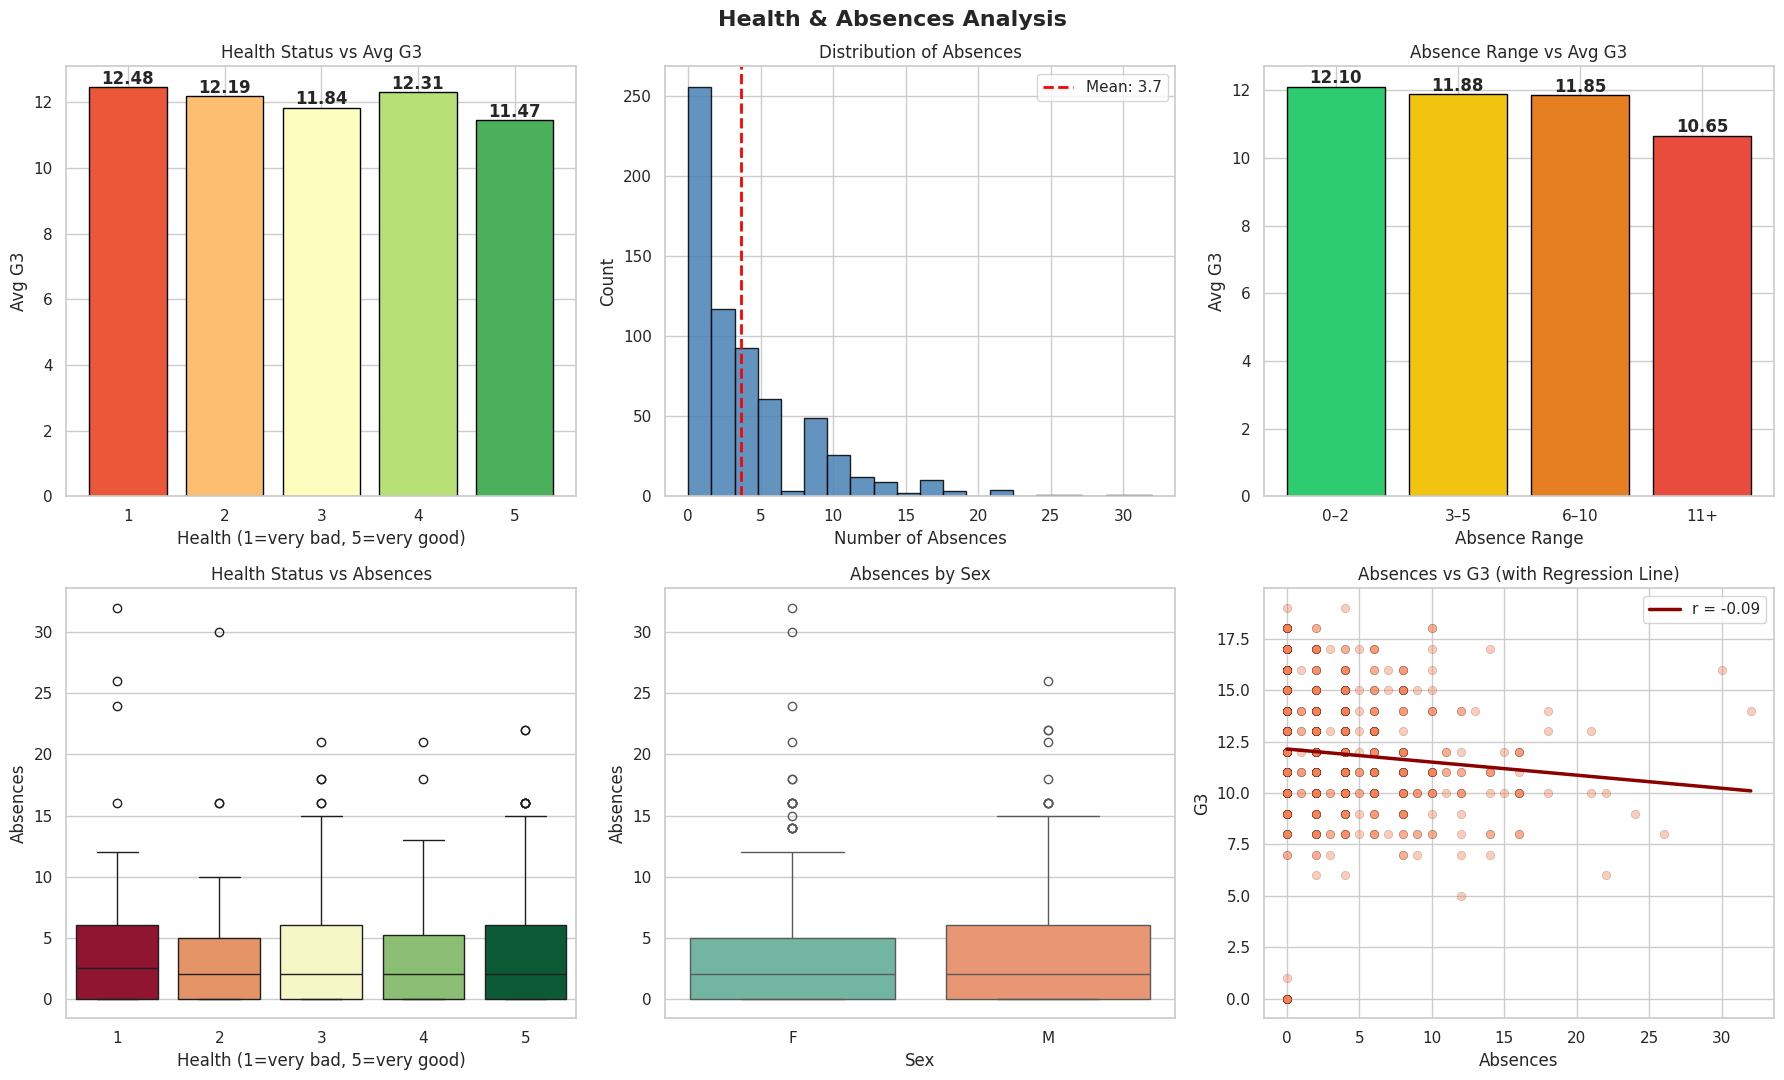

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Health & Absences Analysis", fontsize=16, fontweight='bold')

# Health vs G3
health_avg = df.groupby('health')['G3'].mean()
axes[0,0].bar(health_avg.index, health_avg.values, color=sns.color_palette("RdYlGn", 5), edgecolor='black')
axes[0,0].set_title('Health Status vs Avg G3')
axes[0,0].set_xlabel('Health (1=very bad, 5=very good)')
axes[0,0].set_ylabel('Avg G3')
for i, v in zip(health_avg.index, health_avg.values):
    axes[0,0].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

# Absences distribution
axes[0,1].hist(df['absences'], bins=20, color='steelblue', edgecolor='black', alpha=0.85)
axes[0,1].axvline(df['absences'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {df["absences"].mean():.1f}')
axes[0,1].set_title('Distribution of Absences')
axes[0,1].set_xlabel('Number of Absences')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# Absences vs G3 (binned)
df['absence_bin'] = pd.cut(df['absences'], bins=[0,2,5,10,32],
                            labels=['0–2','3–5','6–10','11+'], include_lowest=True)
abs_avg = df.groupby('absence_bin', observed=True)['G3'].mean()
axes[0,2].bar(abs_avg.index, abs_avg.values, color=['#2ecc71','#f1c40f','#e67e22','#e74c3c'], edgecolor='black')
axes[0,2].set_title('Absence Range vs Avg G3')
axes[0,2].set_xlabel('Absence Range')
axes[0,2].set_ylabel('Avg G3')
for i, v in enumerate(abs_avg.values):
    axes[0,2].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

# Health vs absences
sns.boxplot(data=df, x='health', y='absences', hue='health', palette='RdYlGn',
            ax=axes[1,0], legend=False)
axes[1,0].set_title('Health Status vs Absences')
axes[1,0].set_xlabel('Health (1=very bad, 5=very good)')
axes[1,0].set_ylabel('Absences')

# Absences by sex
sns.boxplot(data=df, x='sex', y='absences', hue='sex', palette='Set2',
            ax=axes[1,1], legend=False)
axes[1,1].set_title('Absences by Sex')
axes[1,1].set_xlabel('Sex')
axes[1,1].set_ylabel('Absences')

# Absences vs G3 scatter with regression
axes[1,2].scatter(df['absences'], df['G3'], alpha=0.4, color='coral', edgecolors='k', linewidths=0.3)
m, b = np.polyfit(df['absences'], df['G3'], 1)
x_range = np.linspace(0, df['absences'].max(), 100)
axes[1,2].plot(x_range, m*x_range + b, color='darkred', linewidth=2.5, label=f'r = {df["absences"].corr(df["G3"]):.2f}')
axes[1,2].set_title('Absences vs G3 (with Regression Line)')
axes[1,2].set_xlabel('Absences')
axes[1,2].set_ylabel('G3')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('health_absences_analysis.png', dpi=150)
plt.show()

# Grade Progression Analysis (G1 → G2 → G3)

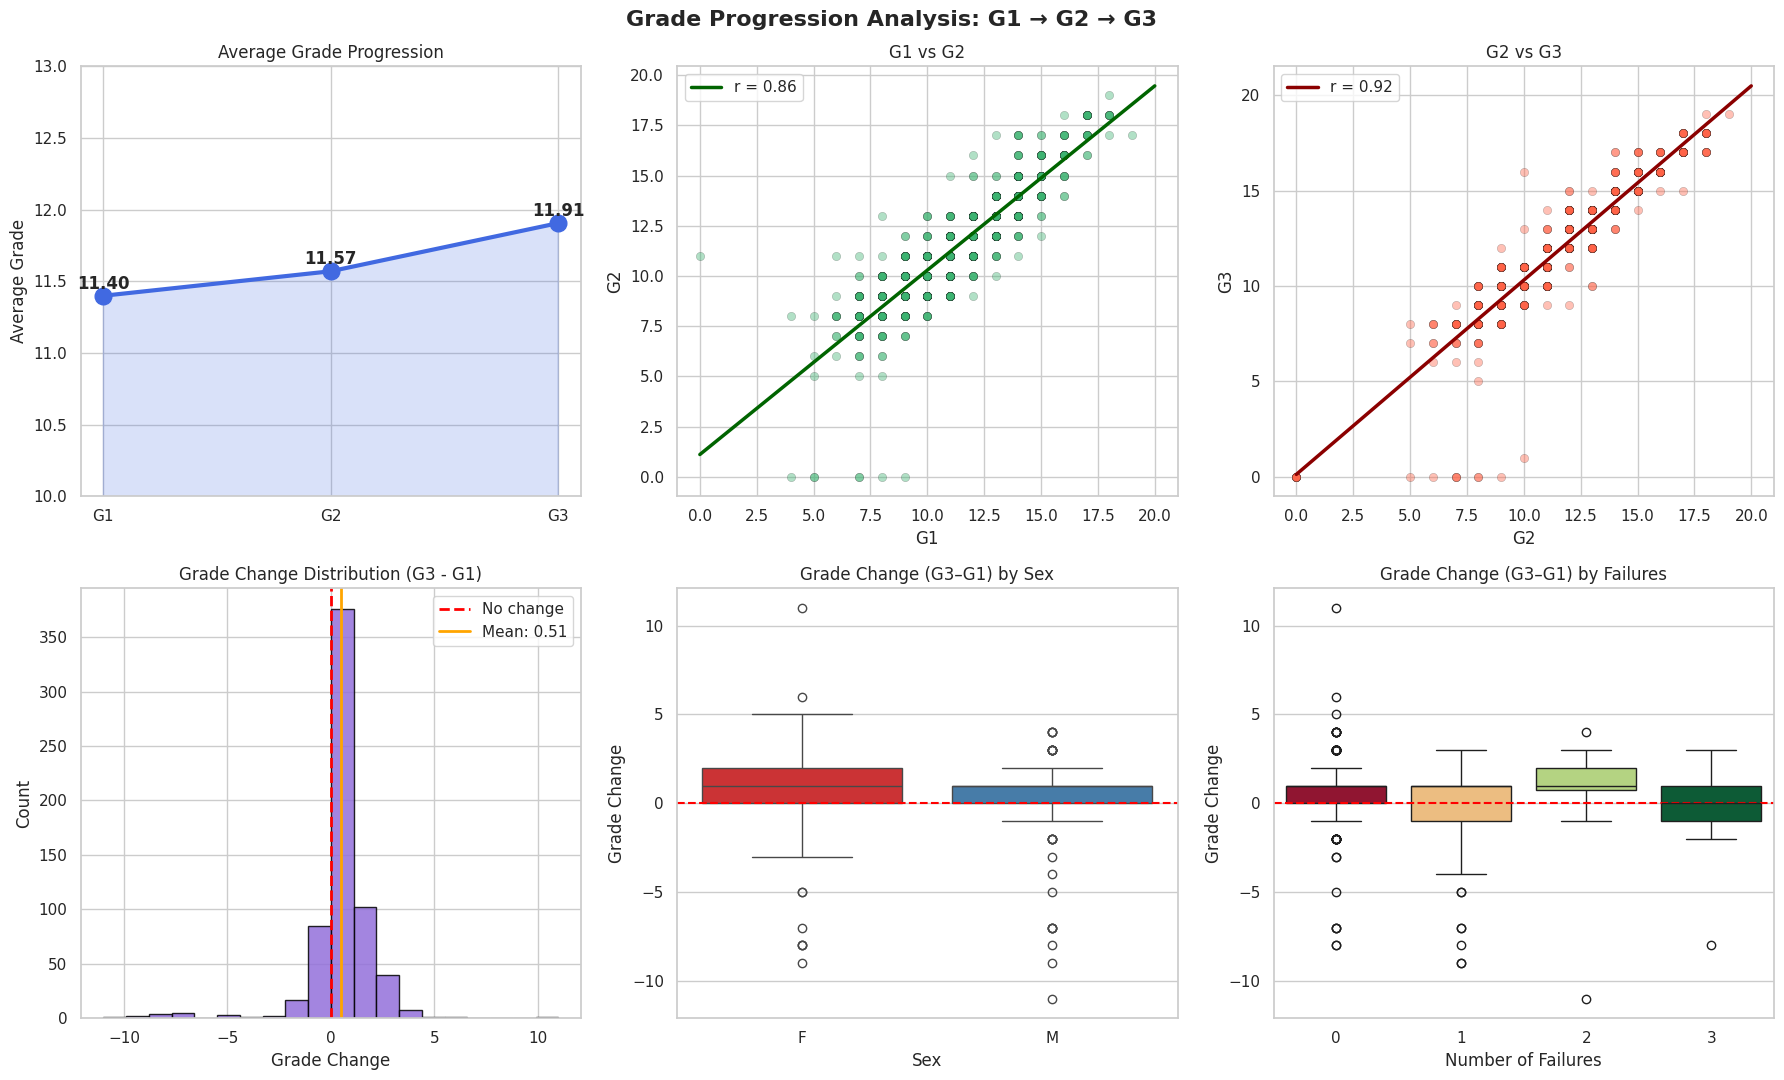


📈 Grade Progression Stats:
  Avg G1: 11.40 | Avg G2: 11.57 | Avg G3: 11.91
  Students who improved (G3 > G1): 344 (53.0%)
  Students who declined  (G3 < G1): 120 (18.5%)
  Students who stayed same (G3=G1): 185 (28.5%)


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Grade Progression Analysis: G1 → G2 → G3", fontsize=16, fontweight='bold')

# Average grade progression
avg_grades = [df['G1'].mean(), df['G2'].mean(), df['G3'].mean()]
axes[0,0].plot(['G1','G2','G3'], avg_grades, marker='o', color='royalblue', linewidth=3, markersize=12)
axes[0,0].fill_between(['G1','G2','G3'], avg_grades, alpha=0.2, color='royalblue')
for i, v in enumerate(avg_grades):
    axes[0,0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold', fontsize=12)
axes[0,0].set_title('Average Grade Progression')
axes[0,0].set_ylabel('Average Grade')
axes[0,0].set_ylim(10, 13)

# G1 vs G2 scatter
axes[0,1].scatter(df['G1'], df['G2'], alpha=0.4, color='mediumseagreen', edgecolors='k', linewidths=0.3)
m, b = np.polyfit(df['G1'], df['G2'], 1)
axes[0,1].plot(np.linspace(0,20,100), m*np.linspace(0,20,100)+b, color='darkgreen', linewidth=2.5,
               label=f'r = {df["G1"].corr(df["G2"]):.2f}')
axes[0,1].set_title('G1 vs G2')
axes[0,1].set_xlabel('G1')
axes[0,1].set_ylabel('G2')
axes[0,1].legend()

# G2 vs G3 scatter
axes[0,2].scatter(df['G2'], df['G3'], alpha=0.4, color='tomato', edgecolors='k', linewidths=0.3)
m, b = np.polyfit(df['G2'], df['G3'], 1)
axes[0,2].plot(np.linspace(0,20,100), m*np.linspace(0,20,100)+b, color='darkred', linewidth=2.5,
               label=f'r = {df["G2"].corr(df["G3"]):.2f}')
axes[0,2].set_title('G2 vs G3')
axes[0,2].set_xlabel('G2')
axes[0,2].set_ylabel('G3')
axes[0,2].legend()

# Grade improvement: G3 - G1
df['grade_change'] = df['G3'] - df['G1']
axes[1,0].hist(df['grade_change'], bins=20, color='mediumpurple', edgecolor='black', alpha=0.85)
axes[1,0].axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
axes[1,0].axvline(df['grade_change'].mean(), color='orange', linestyle='-', linewidth=2,
                   label=f'Mean: {df["grade_change"].mean():.2f}')
axes[1,0].set_title('Grade Change Distribution (G3 - G1)')
axes[1,0].set_xlabel('Grade Change')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# Grade change by sex
sns.boxplot(data=df, x='sex', y='grade_change', hue='sex', palette='Set1',
            ax=axes[1,1], legend=False)
axes[1,1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1,1].set_title('Grade Change (G3–G1) by Sex')
axes[1,1].set_xlabel('Sex')
axes[1,1].set_ylabel('Grade Change')

# Grade change by failures
sns.boxplot(data=df, x='failures', y='grade_change', hue='failures', palette='RdYlGn',
            ax=axes[1,2], legend=False)
axes[1,2].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1,2].set_title('Grade Change (G3–G1) by Failures')
axes[1,2].set_xlabel('Number of Failures')
axes[1,2].set_ylabel('Grade Change')

plt.tight_layout()
plt.savefig('grade_progression.png', dpi=150)
plt.show()

# Summary stats
print("\n📈 Grade Progression Stats:")
print(f"  Avg G1: {df['G1'].mean():.2f} | Avg G2: {df['G2'].mean():.2f} | Avg G3: {df['G3'].mean():.2f}")
print(f"  Students who improved (G3 > G1): {(df['grade_change'] > 0).sum()} ({(df['grade_change'] > 0).mean()*100:.1f}%)")
print(f"  Students who declined  (G3 < G1): {(df['grade_change'] < 0).sum()} ({(df['grade_change'] < 0).mean()*100:.1f}%)")
print(f"  Students who stayed same (G3=G1): {(df['grade_change'] == 0).sum()} ({(df['grade_change'] == 0).mean()*100:.1f}%)")

# Pairplot of Key Features

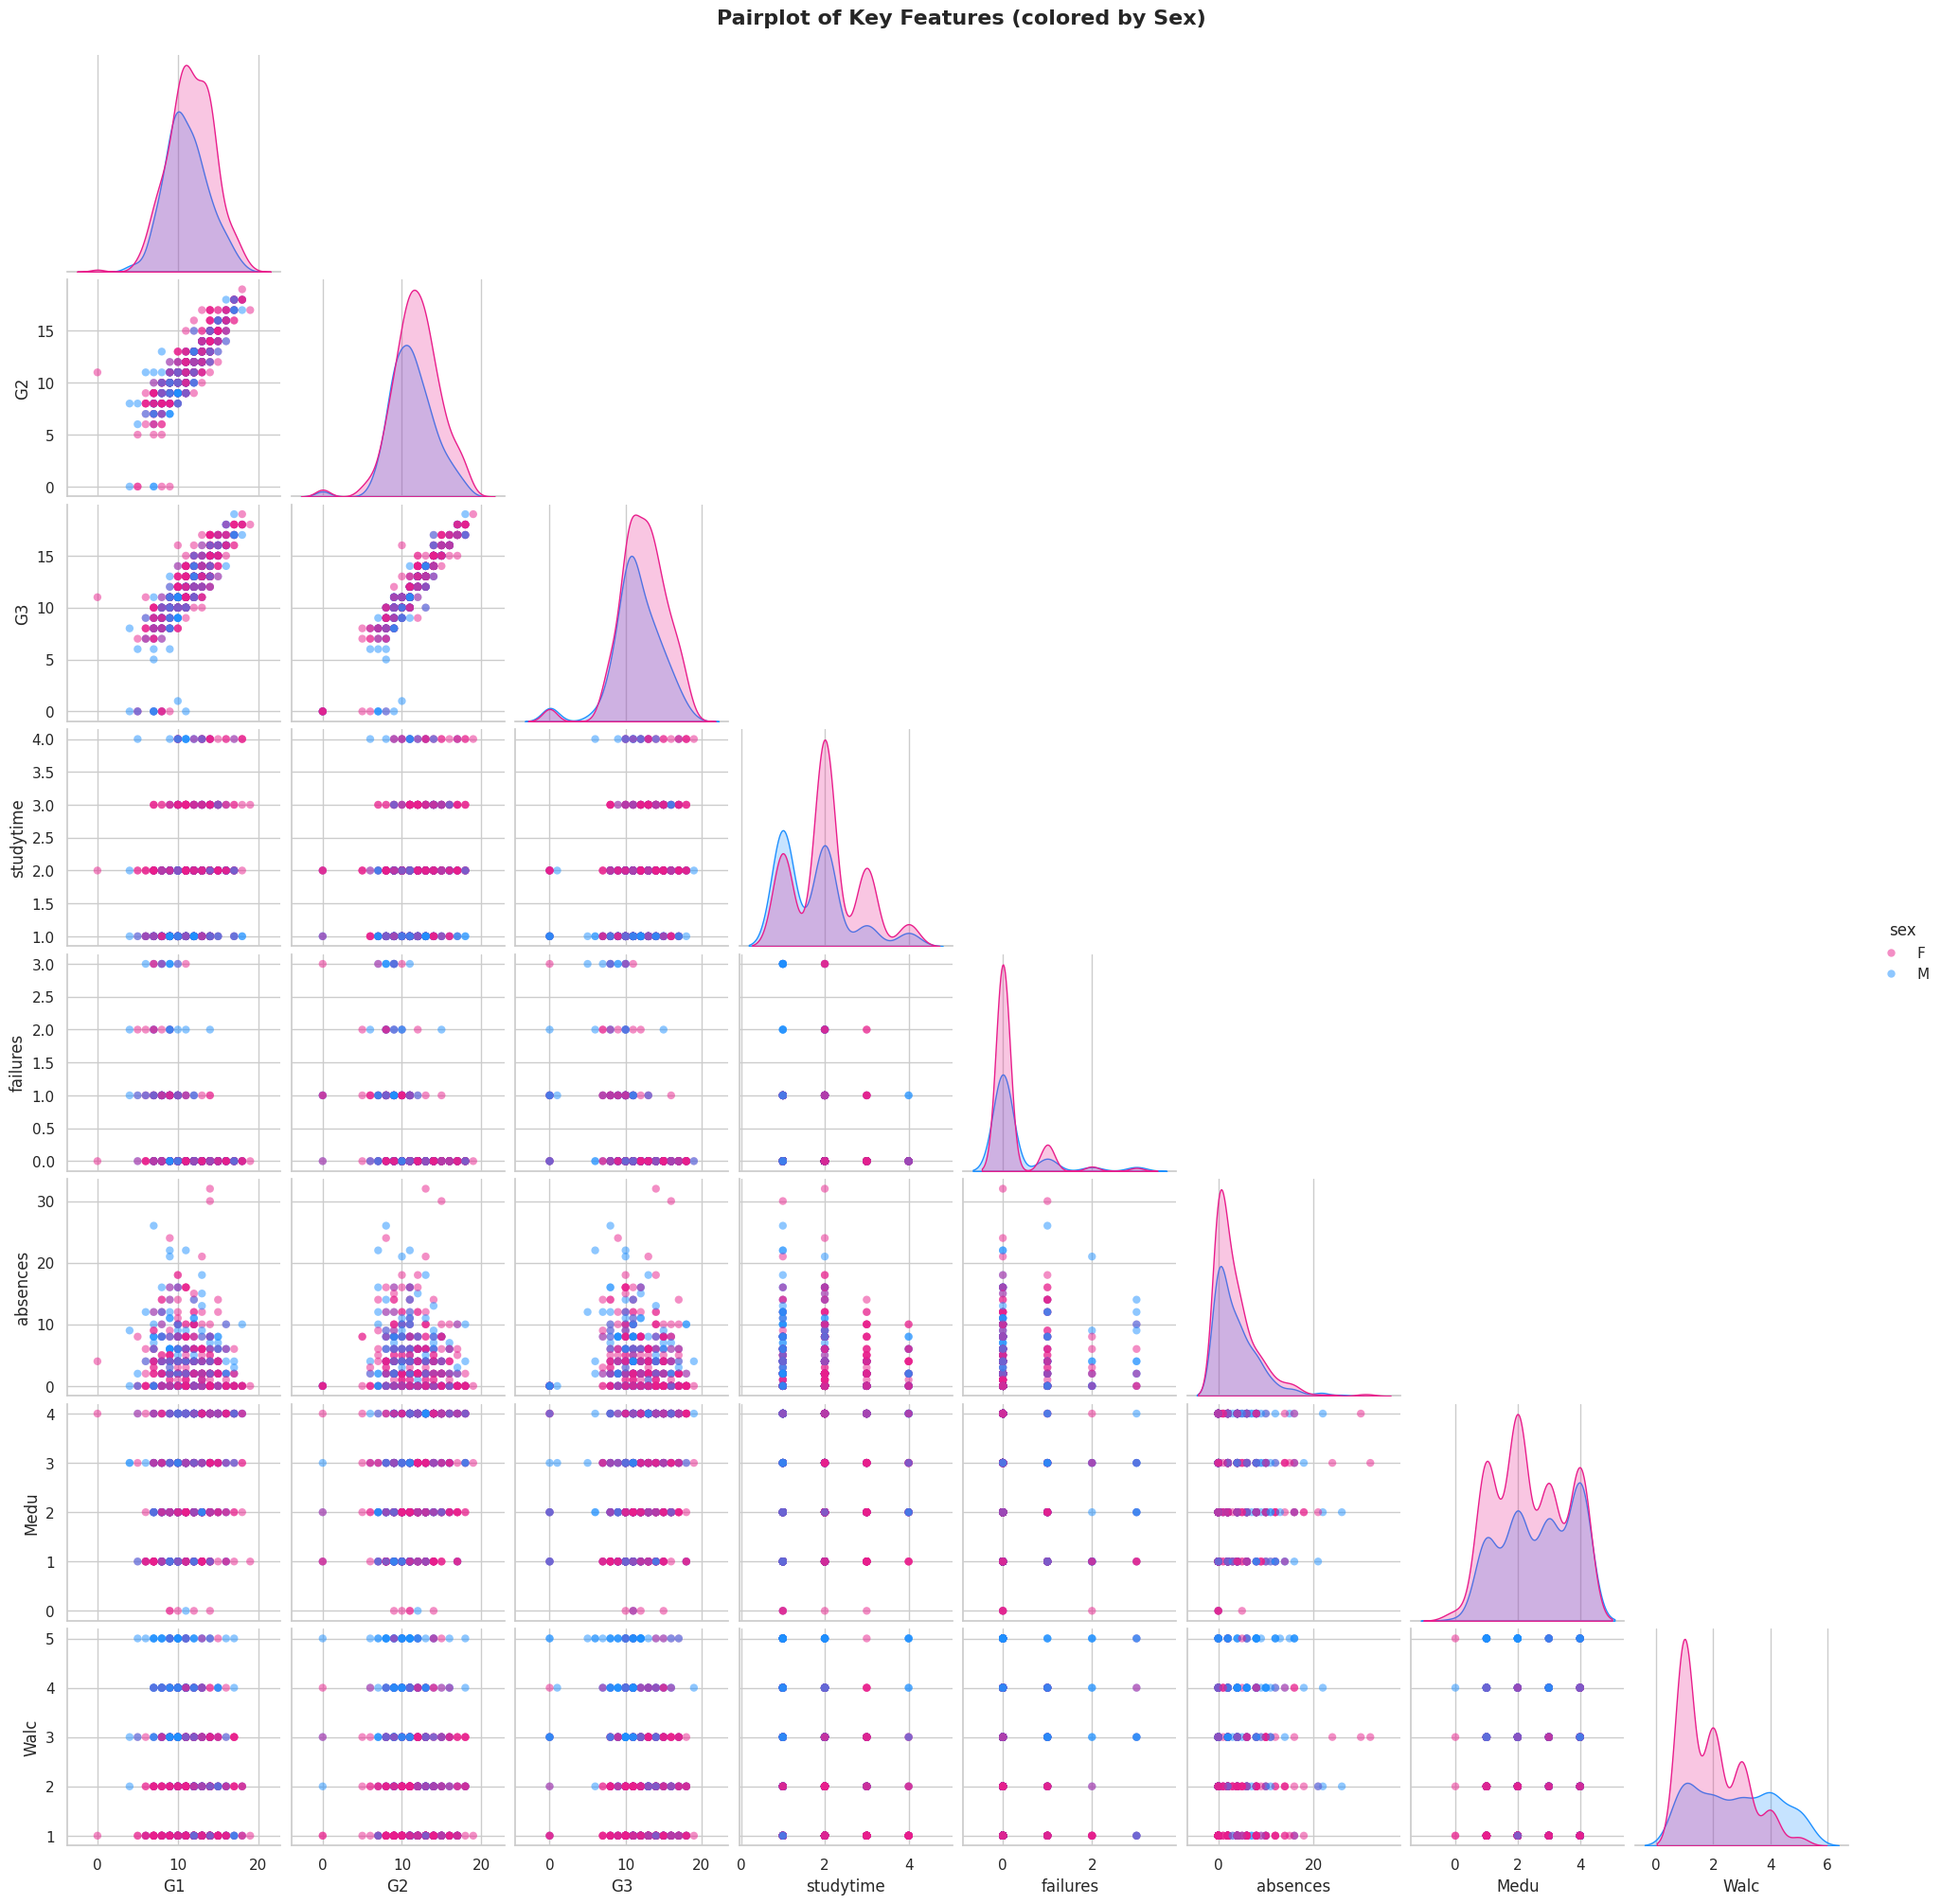

✅ Pairplot complete!


In [23]:
key_features = ['G1', 'G2', 'G3', 'studytime', 'failures', 'absences', 'Medu', 'Walc']

pair_df = df[key_features + ['sex']].copy()

g = sns.pairplot(pair_df, hue='sex', palette={'F': '#E91E8C', 'M': '#1E90FF'},
                 plot_kws={'alpha': 0.5, 'edgecolor': 'none'},
                 diag_kind='kde', corner=True)

g.figure.suptitle("Pairplot of Key Features (colored by Sex)",
                   fontsize=16, fontweight='bold', y=1.01)

plt.savefig('pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Pairplot complete!")

# Feature Engineering (creating useful features)

✅ Engineered Features Created:
       avg_grade  grade_trend  social_score  risk_score  support_score
count     649.00       649.00        649.00      649.00         649.00
mean       11.48         0.17          6.37        4.74           1.55
std         2.73         1.48          1.83        2.50           0.80
min         2.00        -9.00          2.00        2.00           0.00
25%         9.50        -1.00          5.00        2.80           1.00
50%        11.50         0.00          6.00        4.00           2.00
75%        13.50         1.00          8.00        6.00           2.00
max        18.50        11.00         10.00       15.40           4.00


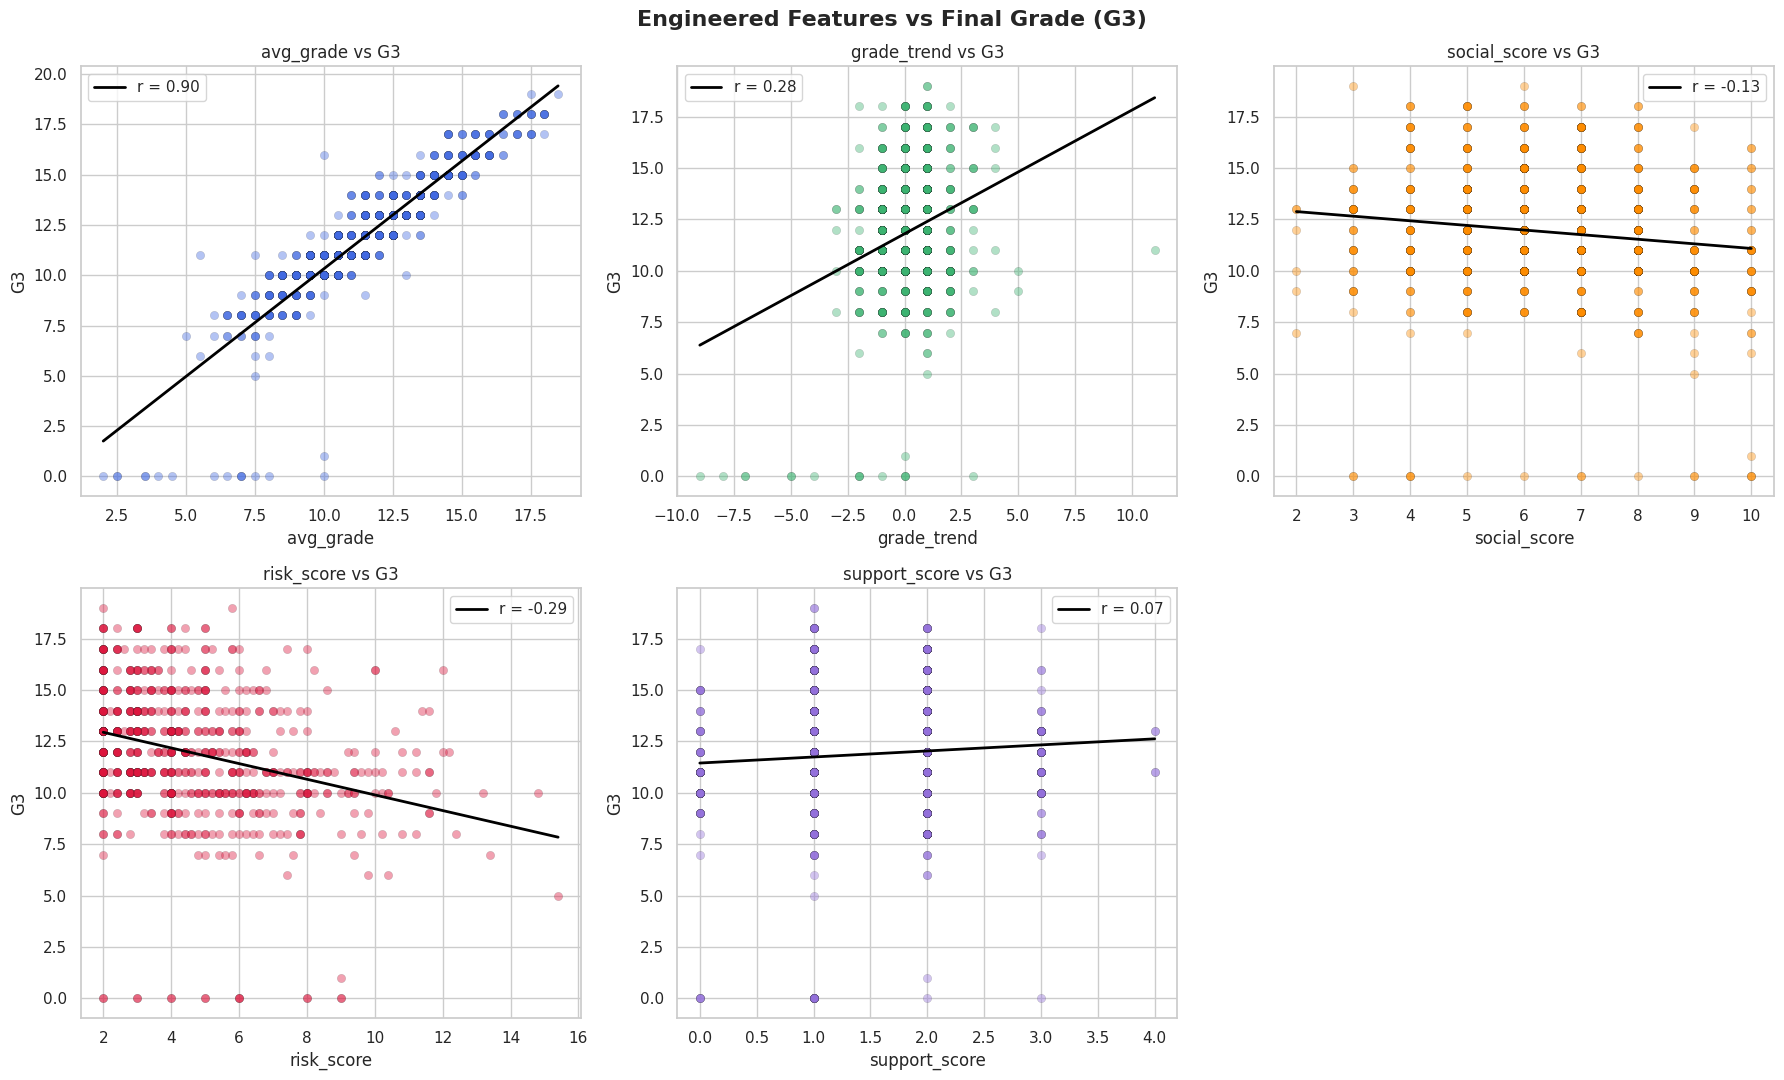

In [24]:
df['avg_grade']       = (df['G1'] + df['G2']) / 2          # avg of first two terms
df['grade_trend']     = df['G2'] - df['G1']                 # improvement from G1→G2
df['social_score']    = df['goout'] + df['freetime']        # overall social activity
df['risk_score']      = df['failures'] + df['Dalc'] + df['Walc'] + df['absences'] / 5
df['support_score']   = (
    (df['schoolsup'] == 'yes').astype(int) +
    (df['famsup']    == 'yes').astype(int) +
    (df['paid']      == 'yes').astype(int) +
    (df['internet']  == 'yes').astype(int)
)

print("✅ Engineered Features Created:")
print(df[['avg_grade','grade_trend','social_score','risk_score','support_score']].describe().round(2))

# Visualise new features vs G3
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Engineered Features vs Final Grade (G3)", fontsize=16, fontweight='bold')

new_features = ['avg_grade', 'grade_trend', 'social_score', 'risk_score', 'support_score']
colors = ['royalblue', 'mediumseagreen', 'darkorange', 'crimson', 'mediumpurple']

for i, (feat, col) in enumerate(zip(new_features, colors)):
    ax = axes[i // 3][i % 3]
    ax.scatter(df[feat], df['G3'], alpha=0.4, color=col, edgecolors='k', linewidths=0.2)
    m, b = np.polyfit(df[feat], df['G3'], 1)
    x_r = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_r, m*x_r + b, color='black', linewidth=2,
            label=f'r = {df[feat].corr(df["G3"]):.2f}')
    ax.set_title(f'{feat} vs G3')
    ax.set_xlabel(feat)
    ax.set_ylabel('G3')
    ax.legend()

axes[1][2].set_visible(False)
plt.tight_layout()
plt.savefig('engineered_features.png', dpi=150)
plt.show()

# Correlation of All Features with G3 (Final Summary Bar Chart)

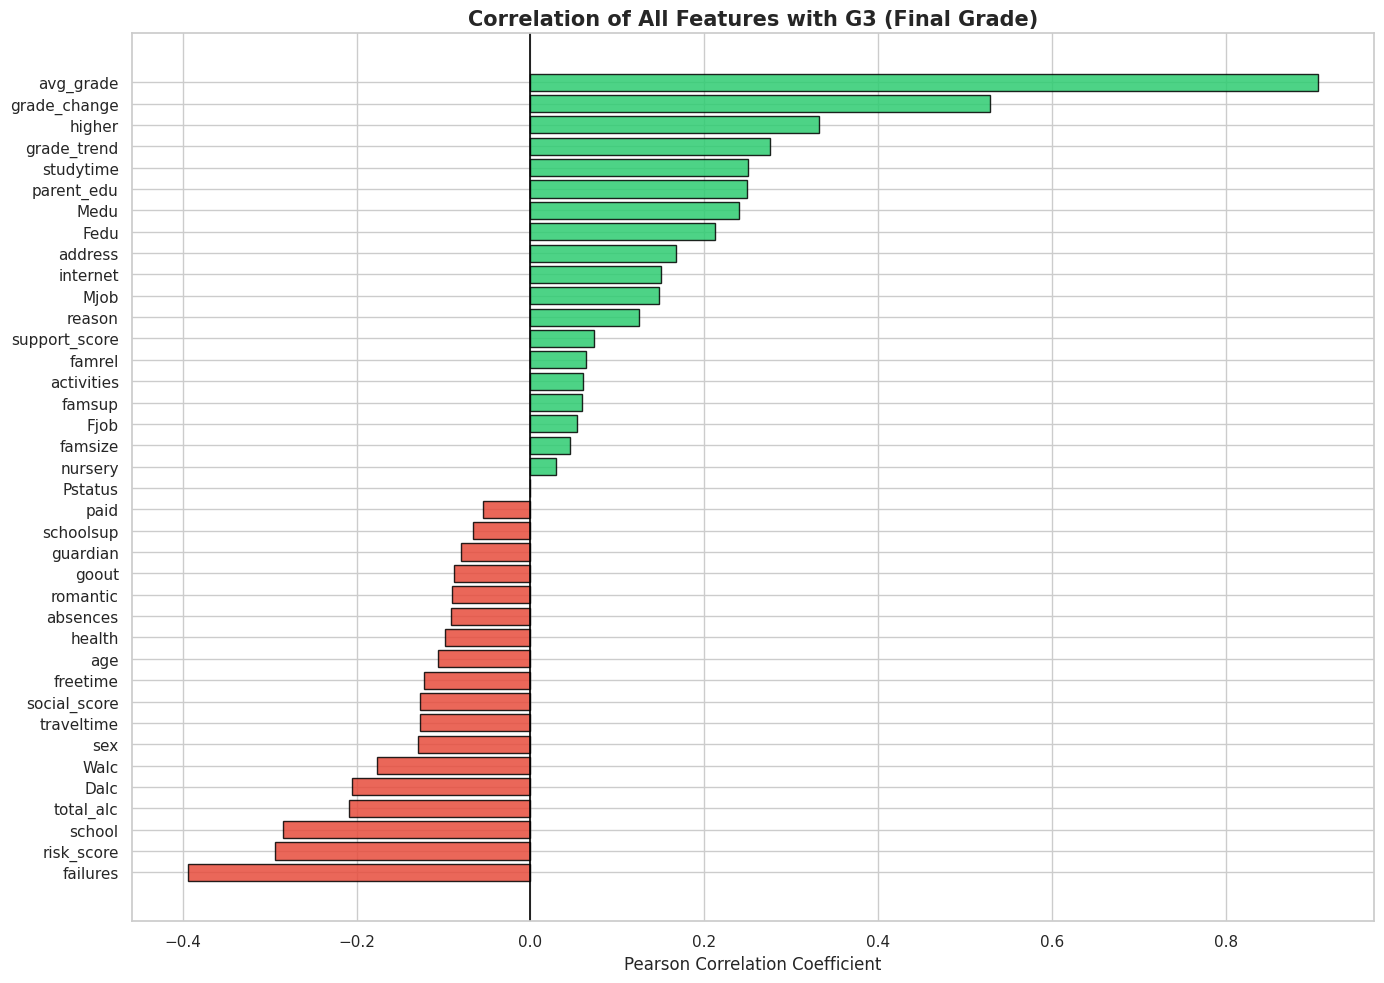


📊 Top 5 Positive Correlators with G3:
studytime       0.250
grade_trend     0.276
higher          0.332
grade_change    0.528
avg_grade       0.905
dtype: float64

📊 Top 5 Negative Correlators with G3:
failures     -0.393
risk_score   -0.294
school       -0.284
total_alc    -0.209
Dalc         -0.205
dtype: float64


In [25]:
# Encode categorical columns for correlation
df_encoded = df.copy()
cat_cols = df_encoded.select_dtypes(include='object').columns
for col in cat_cols:
    df_encoded[col] = pd.Categorical(df_encoded[col]).codes

# Drop non-feature columns
drop_cols = ['G3', 'absence_bin']
num_df = df_encoded.drop(columns=drop_cols, errors='ignore')

correlations = num_df.corrwith(df_encoded['G3']).drop(['G1','G2'], errors='ignore')
correlations = correlations.sort_values()

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in correlations.values]

plt.figure(figsize=(14, 10))
bars = plt.barh(correlations.index, correlations.values, color=colors, edgecolor='black', alpha=0.85)
plt.axvline(0, color='black', linewidth=1.2)
plt.title("Correlation of All Features with G3 (Final Grade)", fontsize=15, fontweight='bold')
plt.xlabel("Pearson Correlation Coefficient")
plt.tight_layout()
plt.savefig('full_correlation_bar.png', dpi=150)
plt.show()

print("\n📊 Top 5 Positive Correlators with G3:")
print(correlations.tail(5).round(3))
print("\n📊 Top 5 Negative Correlators with G3:")
print(correlations.head(5).round(3))